# Stock Trend Predictor



> Бұл жоба — акция бағасының болашақта қалай өзгеретінін болжайтын machine learning жүйесі. Біз екі түрлі мәселені шешеміз:
> - **Regression**: нақты баға өзгерісінің мөлшерін болжау
> - **Classification**: баға өседі ме, жоқ па деп болжау
>
> Болжауды **1 күн, 3 күн және 5 күн** алдына дейін жасаймыз. Model ретінде қарапайым Ridge/Logistic Regression-ды (baseline) және күшті LightGBM-ді қолданамыз.

**Мақсат:** Келесі кезеңдегі акция бағасын болжау (регрессия) және бағытын анықтау (классификация) — 1 күн, 3 күн және 5 күндік горизонттар бойынша.

**Модельдер:** Ridge / Logistic Regression (baseline) vs LightGBM (негізгі модель)  
**Фичалар:** ~10 техникалық индикатор — әрқайсысы қаржылық тұрғыдан түсінікті таңдалған  
**Бағалау:** Стандартты регрессия және классификация метрикалары + overfitting талдауы  
**Интерпретация:** LightGBM feature importance + SHAP мәндері

## 0. Setup

Барлық қажетті кітапханаларды импорт жасаймыз. `sys.path` арқылы `src/` папкасын жол ретінде қосамыз — сонда біздің модульдерімізді Python тауып алады.

In [ ]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 110
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score
import shap

from src.config import DEFAULT_TICKER, HORIZONS, DATA_PERIOD_YEARS
from src.data.loader import load_ohlcv, get_ticker_info
from src.data.preprocessor import validate_ohlcv, add_targets, time_split, get_feature_target_arrays
from src.features.pipeline import build_features, get_feature_columns, add_one_hot_dow
from src.models.regression import RidgeRegressor, LGBMRegressor
from src.models.classification import LogisticClassifier, LGBMClassifier
from src.evaluation.metrics import evaluate_regression, evaluate_classification, summarise_results
from src.evaluation.visualization import (
    plot_price_history, plot_outlier_boxplots, plot_correlation_heatmap,
    plot_regression_metrics, plot_train_val_gap_regression,
    plot_confusion_matrix, plot_classification_metrics,
    plot_train_val_gap_classification, plot_roc_curves,
    plot_feature_importance, plot_shap_summary, plot_horizon_comparison,
)

print('Barlyq importtar satti oryndaldy.')

All imports successful.


## 1. Data Loading

We fetch 5 years of daily OHLCV data via **yfinance** with `auto_adjust=True` so prices are adjusted for stock splits and dividends. Adjusted prices are essential — unadjusted prices show discontinuous jumps at split/dividend events that would be interpreted as extreme returns by the model.


> **yfinance** арқылы соңғы 5 жылдың күнделікті OHLCV деректерін аламыз:
> - **O**pen — ашылу бағасы
> - **H**igh — күндегі ең жоғары баға
> - **L**ow — күндегі ең төменгі баға
> - **C**lose — жабылу бағасы
> - **V**olume — сатылған акциялар саны
>
> `auto_adjust=True` параметрі маңызды — ол акция бөлінуі (stock split) мен дивиденд кезінде бағаларды автоматты реттейді. Реттелмеген баға деректері модельге бұрмаланған сигнал береді.

In [ ]:
TICKER = DEFAULT_TICKER   # Кез келген тикерге өзгертіңіз: 'MSFT', 'TSLA', 'SPY', т.б.
# Тикер туралы ақпаратты алу
info = get_ticker_info(TICKER)
print(f"Ticker  : {info['name']}")
print(f"Sector  : {info['sector']}")
print(f"Currency: {info['currency']}")
print()
# Баға деректерін жүктеу (OHLCV)
df_raw = load_ohlcv(TICKER)

# Күндер аралығы мен сауда күндерінің саны
print(f"Date range : {df_raw.index.min().date()} → {df_raw.index.max().date()}")
print(f"Trading days: {len(df_raw)}")
df_raw.head()

Ticker  : MSFT
Sector  : N/A
Currency: USD

Date range : 2021-04-08 → 2026-04-07
Trading days: 1255


,Open,High,Low,Close,Volume
Date,,,,,
2026-03-31,364.549988,372.899994,363.070007,370.170013,45244400.0
2026-04-01,373.489990,373.989990,368.200012,369.369995,29417200.0
2026-04-02,367.209991,373.640015,364.149994,373.459991,24099100.0
2026-04-06,373.489990,373.730011,369.500000,372.880005,16146600.0
2026-04-07,370.339996,372.450012,366.559998,372.290009,20760900.0


## 2. Data Validation & Cleaning

> Деректерді жүктегеннен кейін оларды тексеру керек. Мысалы:
> - Күннің ең жоғары бағасы (High) ең төменгіден (Low) кіші бола алмайды
> - Close бағасы High мен Low арасында болуы керек
> - Баға немесе volume нөлден кіші болмауы керек
>
> Жоғалып кеткен мәндерді (NaN) алдыңғы мәнмен толтырамыз (forward-fill).

**Неге forward-fill (ffill) бизнес тұрғысынан маңызды?**

- **Реалистік сценарий:** Егер жаңа дерек жоқ болса, соңғы белгілі мәнге сүйену — нарықтағы нақты жағдайға жақын  
- **Тұрақты модель:** Үзілмеген деректер → модель тұрақты жұмыс істейді және болжам сапасы жоғары  

 **Өзгеше көрінетін барлық қатарларды өшіре алмаймыз** , себебі қаржы деректерінде экстремалды мәндер кейде шынайы оқиғалар болады: нарық дағдарысы, үлкен жаңалықтар.

In [ ]:
# Деректерді тексеру және тазалау (validation)
df_clean = validate_ohlcv(df_raw)

# Тазалаудан кейінгі жолдар саны
print(f"Rows after validation: {len(df_clean)}")

# Негізгі статистикалық сипаттамалар
df_clean.describe().round(2)

Rows after validation: 1255



,Open,High,Low,Close,Volume
count,1255.00,1255.00,1255.00,1255.00,1.255000e+03
mean,358.10,361.36,354.61,351.88,2.580872e+07
std,84.42,84.62,83.94,86.40,1.069250e+07
min,217.55,220.41,213.43,208.18,5.855900e+06
25%,284.14,287.67,280.52,275.20,1.892270e+07
50%,339.56,343.00,337.20,331.23,2.327770e+07
75%,421.67,425.24,417.82,415.99,2.965220e+07
max,555.23,555.45,540.77,539.83,1.288553e+08


## 3. Exploratory Data Analysis (EDA)

### 3.1 Price History

 **Қазақша түсіндірме**
>
> Деректерді зерттеу бөлімінде алдымен акцияның жабылу бағасының уақыт бойынша өзгеруін қарастырамыз. Бұл жалпы тенденцияны түсінуге және деректерде күтпеген секірістер бар-жоғын тексеруге көмектеседі.

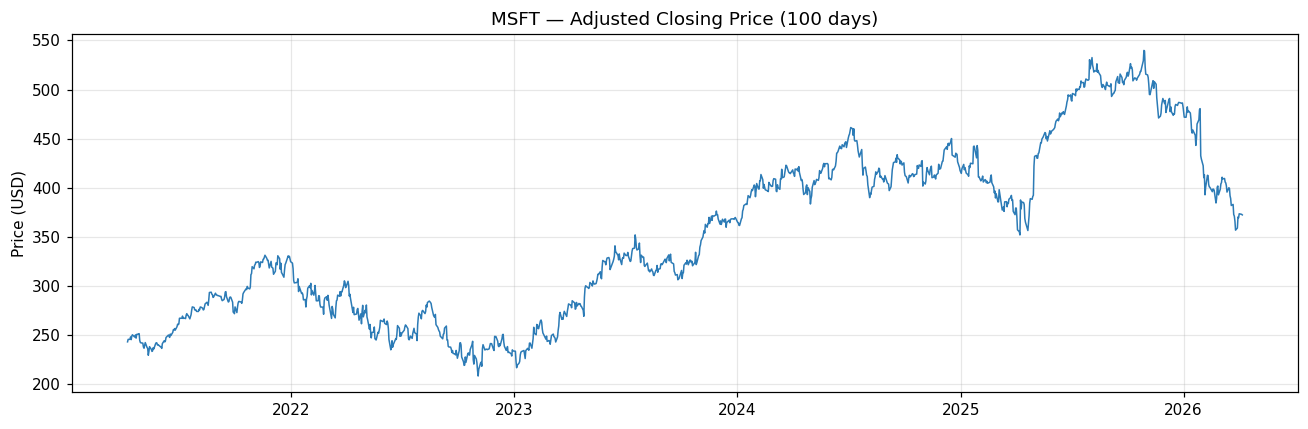

In [4]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_clean.index, df_clean['Close'], linewidth=1, color='#2c7bb6')
ax.set_title(f'{TICKER} — Adjusted Closing Price (5 years)')
ax.set_ylabel('Price (USD)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 3.2 Return Distribution

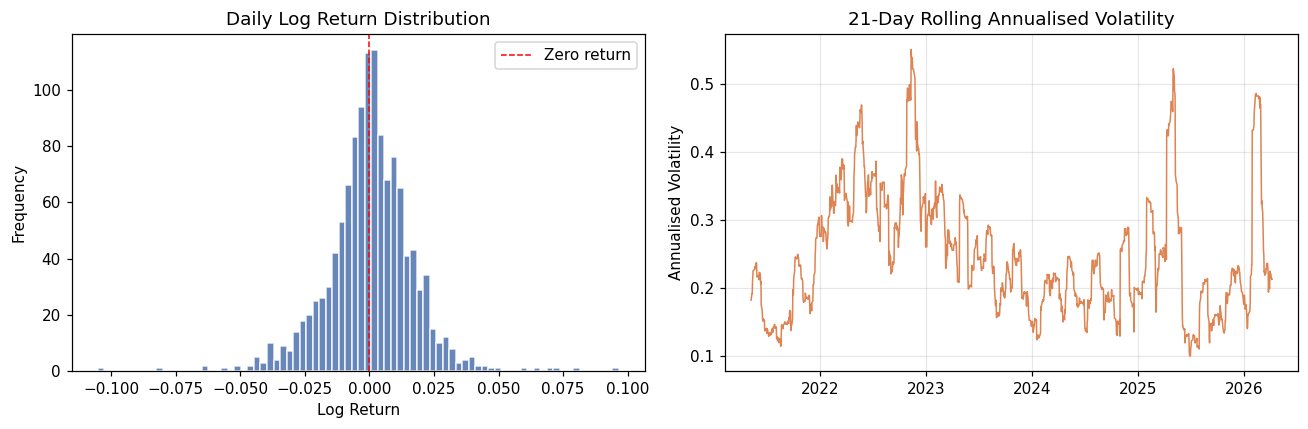

Annualised return    : 8.57%
Annualised volatility: 26.15%
Skewness             : -0.125  (negative = fat left tail)
Excess kurtosis      : 4.017  (>0 = heavier tails than normal)


In [ ]:
# Log return есептеу (күнделікті табыс)
daily_ret = np.log(df_clean['Close'] / df_clean['Close'].shift(1)).dropna()

# 2 график жасау: distribution + volatility
fig, axes = plt.subplots(1, 2, figsize=(12, 4))


# Return distribution (нарықтағы өзгерістер таралуы)
axes[0].hist(daily_ret, bins=80, color='#4C72B0', edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1 )
axes[0].set_title('Daily Log Return Distribution')
axes[0].set_xlabel('Log Return')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# 21 күндік rolling volatility (қысқа мерзімді тәуекел) тәуекел деңгейі  
rolling_vol = daily_ret.rolling(21).std() * np.sqrt(252)

# Волатильдіктің уақыт бойынша өзгерісі
axes[1].plot(daily_ret.index, rolling_vol, color='#DD8452', linewidth=1)
axes[1].set_title('21-Day Rolling Annualised Volatility')
axes[1].set_ylabel('Annualised Volatility')
axes[1].grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

# Жылдық табыс
ann_ret = daily_ret.mean() * 252


# Жылдық тәуекел (волатильдік)
ann_vol = daily_ret.std() * np.sqrt(252)


print(f"Annualised return    : {ann_ret:.2%}")
print(f"Annualised volatility: {ann_vol:.2%}")

# Асимметрия (risk бағытын түсіну)
print(f"Skewness             : {daily_ret.skew():.3f}  (negative = fat left tail)")

# Экстремалды жағдайларды өлшеу
print(f"Excess kurtosis      : {daily_ret.kurtosis():.3f}  (>0 = heavier tails than normal)")

**Лог-ретёрн (Log Return) деген не?**

**Лог-ретёрн** — бұл актив бағасының өзгерісін өлшеудің әдісі. Ол бағаның жай айырмасын емес, екі уақыттағы бағалардың қатынасының логарифмін қолданады.

$$
r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)
$$

мұндағы:

$P_t$ — ағымдағы баға

$P_{t-1}$ — алдыңғы баға

**Неге log return қолданамыз, бағаның өзін емес?**

Бағаның өзі модель үшін маңызды емес, себебі оның масштабы әртүрлі болуы мүмкін.
Ал log return бағаның нақты қалай өзгергенін көрсетеді, сондықтан ол негізгі сигнал болып табылады.
Модель бағаның деңгейін жаттап алуы мүмкін, бірақ заңдылықты үйренбейді.

Мысалы, баға:
100 → 110 → 121

📉 Жай процентпен:
1-күн: (110−100)/100 = 10%
2-күн: (121−110)/110 = 10%

Бірақ жалпы өсім: 21% (жай қосылмайды)

🔄 Log return:
1-күн: ln(110/100) ≈ 0.095
2-күн: ln(121/110) ≈ 0.095

Жалпы:
0.095 + 0.095 = 0.19 


**Skewness (асимметрия):**

- Return таралуының қай жаққа “қисайғанын” көрсетеді  
- Теріс (negative) → сол жақ tail ауыр → үлкен құлдыраулар жиі  

 **Бизнес мәні:**
- Downside risk жоғары  
- Күтпеген үлкен шығын ықтималдығы бар  
- Risk management (stop-loss, hedging) маңызды 

---

**Excess Kurtosis (құйрықтардың ауырлығы):**

- Таралудағы экстремалды мәндердің жиілігін көрсетеді  
- >0 → normal distribution-нан ауыр tail → extreme events жиі  

---

**Қысқаша:**
- Skewness → қай бағытта risk көп (төмен бе, жоғары ма)  
- Kurtosis → қаншалықты extreme жағдайлар жиі болады 

### 3.3 Outlier Analysis — OHLCV



Boxplot — деректердің таралуын және шеткі мәндерді (outlier) визуалды түрде көрудің қарапайым тәсілі. Қаржы деректерінде шеткі мәндер жиі шынайы оқиғалар болады: нарықтық дағдарыс, компания туралы үлкен жаңалықтар және т.б.

Сондықтан оларды деректен өшіріп тастамаймыз. Кейінірек **winsorization** арқылы тек шеттерін ғана кесеміз — яғни ең жоғары 1% және ең төменгі 1% мәндерді белгілі 
бір шекке дейін қысқартамыз.

**Winsorization** — бұл деректердегі **өте үлкен немесе өте кіші мәндерді (outliers)** алып тастамай,  
оларды шеткі шектермен **ауыстыру әдісі**.

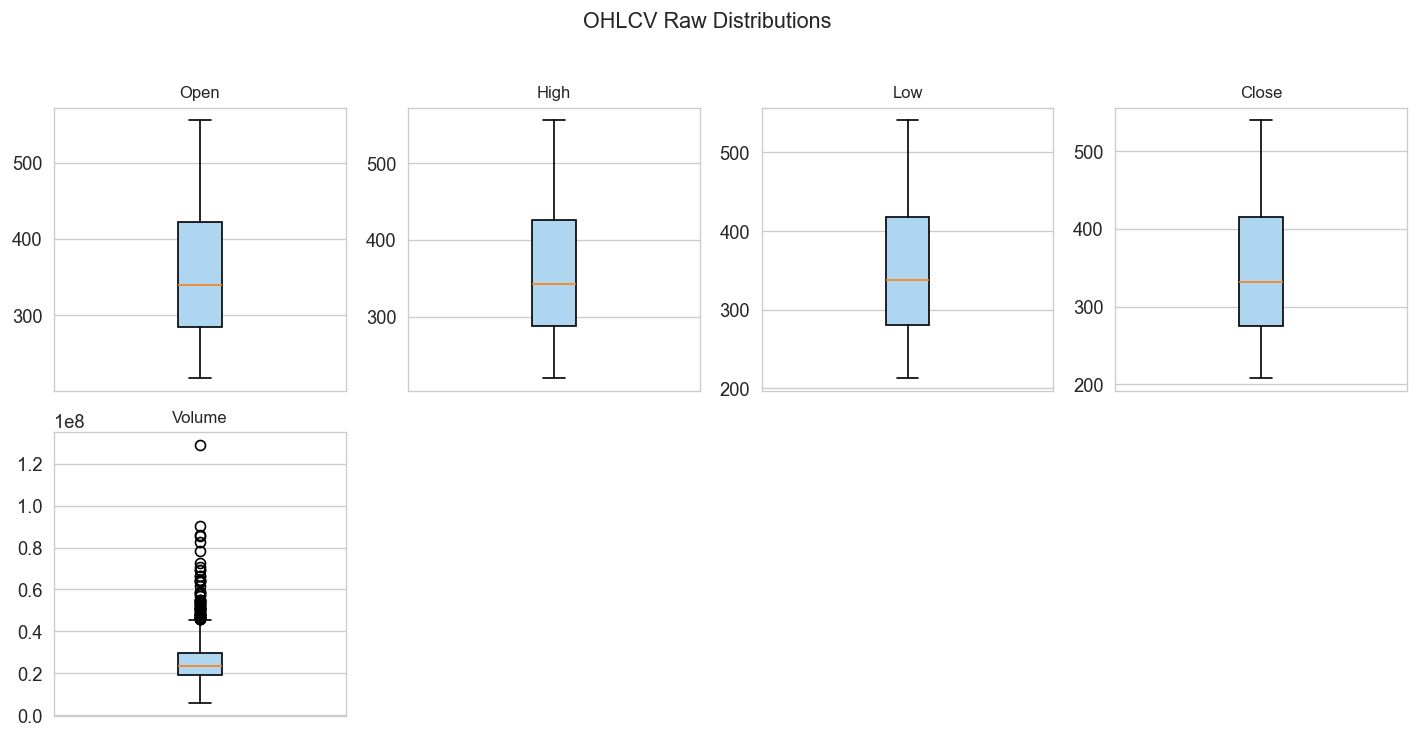

In [ ]:
fig = plot_outlier_boxplots(df_clean, ['Open', 'High', 'Low', 'Close', 'Volume'])
plt.suptitle('OHLCV Raw Distributions', fontsize=13, y=1.02)
plt.show()

**Outlier Analysis (OHLCV):**

**1. Баға көрсеткіштері (Open, High, Low, Close):**
- Әдетте баға деректері салыстырмалы түрде тұрақты диапазонда жатады  
- Outlier-лар сирек кездеседі, бірақ пайда болса — бұл маңызды нарықтық оқиғаларды білдіреді (жаңалықтар, earnings, macro әсерлер)  
Бизнес: бағадағы outlier-лар — тренд өзгерісінің немесе жоғары volatility кезеңінің сигналы  

**2. Volume:**
- Volume деректерінде көбіне айқын outlier-лар болады  
- Бұл сауда белсенділігінің күрт артуын көрсетеді  
Бизнес: volume spikes — нарықтағы маңызды оқиғалардың (panic, hype, institutional activity) индикаторы  


### 3.4 Volume Analysis



Volume (сату көлемі) — сол күні алынып-сатылған акциялар саны. Егер баға күрт өзгерсе, бірақ volume аз болса — бұл сенімсіз сигнал. Ал volume күрт өссе, маңызды оқиға болды деген белгі.

Бұл ақпаратты деректен өшірмейміз — кейінірек `vol_ratio_20d` feature ретінде пайдаланамыз: бүгінгі volume-ды соңғы 20 күннің орташасымен бөлеміз.

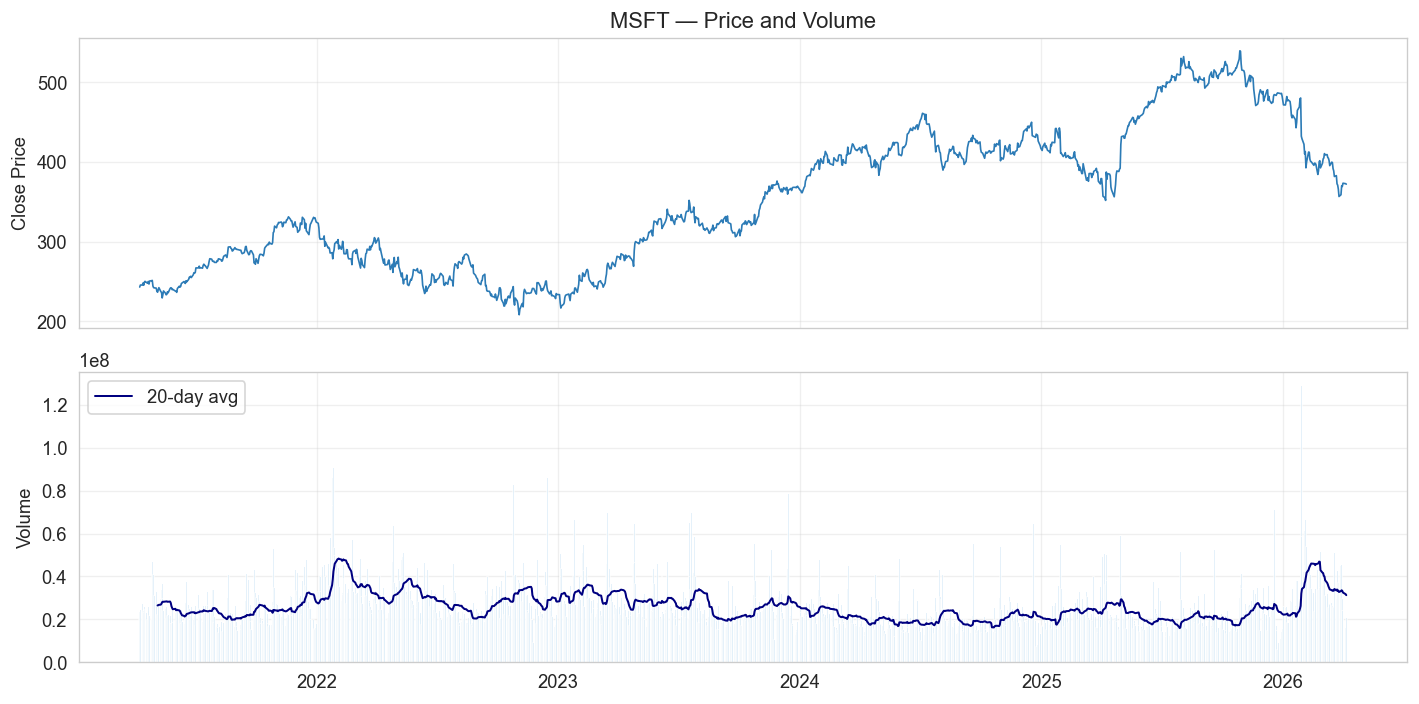

In [ ]:
# Графиктерді жасау: баға және көлем (volume)
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# --- 1. Баға графигі (Close price) ---
axes[0].plot(df_clean.index, df_clean['Close'], linewidth=1, color='#2c7bb6')
axes[0].set_ylabel('Close Price')
axes[0].set_title(f'{TICKER} — Price and Volume')
axes[0].grid(True, alpha=0.3)

# --- 2. Volume графигі ---
# Күнделікті сауда көлемі (bar chart)
axes[1].bar(df_clean.index, df_clean['Volume'], color='#85C1E9', width=1.5, alpha=0.7)

# 20 күндік орташа көлем (trend көру үшін)
vol_ma = df_clean['Volume'].rolling(20).mean()
axes[1].plot(df_clean.index, vol_ma, color='navy', linewidth=1.2, label='20-day avg')
axes[1].set_ylabel('Volume')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Price & Volume Analysis (жалпы интерпретация):**

**Price (баға динамикасы):**
- Трендті көруге болады (өсу / төмендеу / боковик)  
- Баға қозғалысы нарықтағы жалпы бағытты көрсетеді  
 Бизнес: тренд → инвестициялық шешімнің негізі (buy / sell / hold)



**Volume (сауда көлемі):**
- Volume spikes (күрт өсімдер) байқалуы мүмкін  
- Көлемнің өзгеруі нарықтағы белсенділікті көрсетеді  
Бизнес: жоғары volume → маңызды оқиға немесе күшті қозғалыс сигналы  



**Price + Volume байланысы:**
- Баға өсіп + volume өссе → тренд күшейіп жатыр   
- Баға өсіп, бірақ volume аз → сенімсіз өсім  
- Баға түсіп + volume өссе → panic selling (нарық стрессі)  

**Moving Average (20-day volume):**
- Нарықтың “қалыпты” көлем деңгейін көрсетеді  
- Қазіргі volume-ды осы baseline-пен салыстыруға болады  
 Бизнес: ортадан жоғары болса → ерекше белсенділік  


## 4. Feature Engineering

### Неге  Features маңызды

Жай баға (price) дерегі өте “шулы” — одан нақты сигнал алу қиын.  
Сондықтан біз оны **9 түсінікті көрсеткішке** айналдырамыз. Бұл көрсеткіштер нарықтың әртүрлі қырын көрсетеді:
- баға қай бағытта жүріп жатыр (trend)
- тәуекел деңгейі (risk)
- нарықтағы белсенділік (volume)
- баға қаншалықты қатты ауытқиды (volatility)

Барлық feature-лар тек өткен деректерден есептеледі. 
  
Болашақ ақпаратты ешқашан пайдаланбаймыз — бұл **data leakage** деп аталады және нәтижелерді жалған жақсы көрсетеді.

### Feature Table

| Feature | Official Term | Не көрсетеді |
|---|---|---|
| `ret_1d_lag` | 1-day lagged return | Кеше баға өсті ме, түсті ме | 
| `ret_5d_lag` | 5-day lagged return | Өткен аптада акция қалай қозғалды? |
| `ret_21d_lag` | 21-day lagged return | Өткен айда акция қалай қозғалды? |
| `rsi_14` | Relative Strength Index (RSI, 14-period) | Баға тым қымбат па (RSI > 70), тым арзан ба (RSI < 30)? |
| `macd_hist` |  MACD Histogram (Moving Average Convergence Divergence Histogram) | Қозғалыс күшейіп жатыр ма, әлде әлсіреп жатыр ма |
| `bb_pct_b` | Bollinger Bands %B  | Баға өзінің қалыпты диапазонының қай жерінде |
| `rvol_21d` | 21-day rolling volatility |Соңғы уақытта нарық қаншалықты “шулы” |
| `vol_ratio_20d` | Volume ratio (current volume / 20-day average volume) | Бүгінгі сауда көлемі ерекше жоғары ма, төмен ба? |
| `atr_ratio` | Average True Range (ATR) normalized by price | Баға күн ішінде қаншалықты қатты қозғалады  |

**Неге дәл осы 9 фича?**

Бастапқыда 11 фича қарастырылды, бірақ кейбіреуі пайда әкелмей, тек noise қосқандықтан алып тасталды:

- `sma_5_21_ratio` — басқа return фичаларды қайталайды (жаңа ақпарат қоспайды)  
- `rvol_5d` — 5 күндік уақыт тым қысқа, нәтижесі тұрақсыз; 21 күндік нұсқа сенімдірек  
- `day_of_week` — бір акцияның 10 жылдық дерегі апталық pattern-дарды (дүйсенбі/жұма эффекті) сенімді үйренуге жеткіліксіз  

---

**Қорытынды:**
Тек модельге нақты сигнал беретін, қайталанбайтын және тұрақты фичалар таңдалды


In [8]:
df_features = build_features(df_clean)

new_cols = [c for c in df_features.columns if c not in df_clean.columns]
print(f"Rows after feature engineering : {len(df_features)}")
print(f"Features added ({len(new_cols)}): {new_cols}")
print()

# Quick stats on features
tree_cols = get_feature_columns(linear=False)
df_features[tree_cols].describe().round(4)

Rows after feature engineering : 1234
Features added (9): ['ret_1d_lag', 'ret_5d_lag', 'ret_21d_lag', 'rsi_14', 'macd_hist', 'rvol_21d', 'bb_pct_b', 'vol_ratio_20d', 'atr_ratio']



,ret_1d_lag,ret_5d_lag,ret_21d_lag,rsi_14,macd_hist,rvol_21d,bb_pct_b,vol_ratio_20d,atr_ratio
count,1234.0000,1234.0000,1234.0000,1234.0000,1234.0000,1234.0000,1234.0000,1234.0000,1234.0000
mean,0.0003,0.0019,0.0074,52.8420,-0.0427,0.2471,0.5417,1.0037,0.0331
std,0.0153,0.0336,0.0673,12.4762,1.6279,0.0901,0.3251,0.3284,0.0114
min,-0.0430,-0.0847,-0.1599,22.2928,-3.8728,0.1166,-0.2985,0.5183,0.0143
25%,-0.0078,-0.0200,-0.0367,43.4078,-1.1902,0.1809,0.2728,0.7940,0.0233
50%,0.0005,0.0047,0.0089,52.3781,-0.0755,0.2274,0.5715,0.9223,0.0314
75%,0.0098,0.0235,0.0526,62.3928,1.1558,0.3030,0.8176,1.1107,0.0446
max,0.0401,0.0849,0.1626,81.7427,4.0010,0.5059,1.2991,2.4086,0.0545


Winsorization-нан кейін feature-лардың таралуын тексереміз. Boxplot-тар экстремалды мәндердің кесілгенін, бірақ негізгі деректердің өзгермегенін растайды. Бұл қадам деректер дайындауда дұрыс жасалғанын визуалды тексеру.

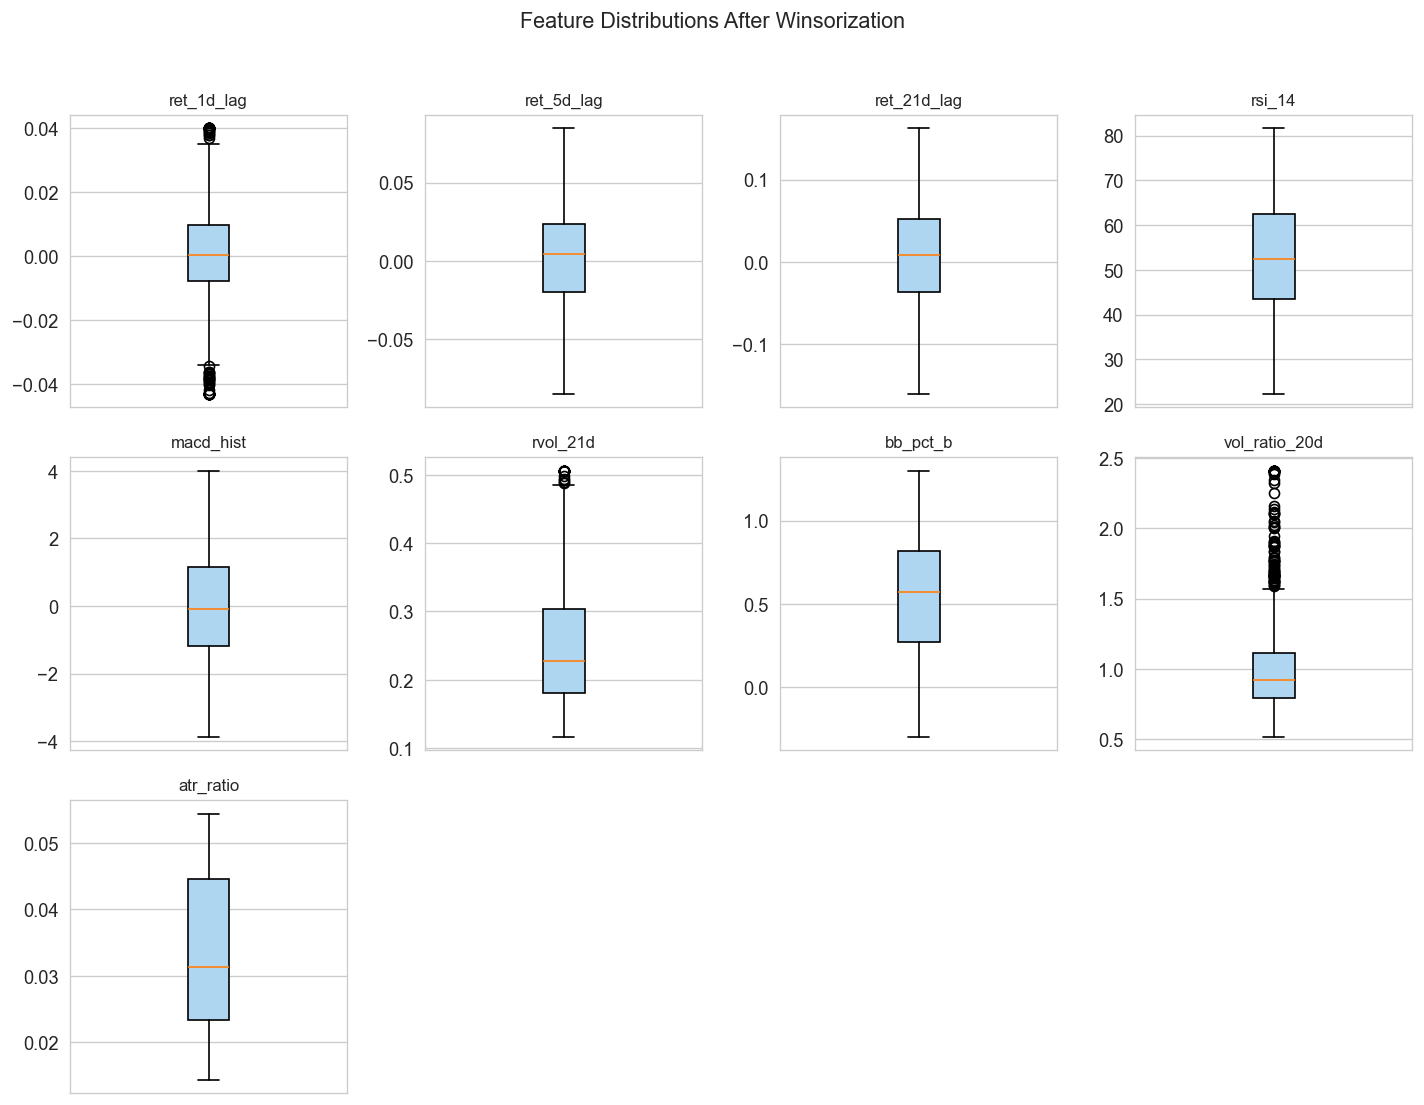

In [9]:
numeric_feats = [c for c in tree_cols if c != 'day_of_week']
fig = plot_outlier_boxplots(df_features, numeric_feats)
plt.suptitle('Feature Distributions After Winsorization', fontsize=13, y=1.02)
plt.show()

**Feature Distributions After Winsorization:**

- Экстремалды мәндер (outliers) қысқартылды → деректер тұрақтырақ болды  
- Негізгі таралу (distribution) сақталды → маңызды ақпарат жоғалмады  


**Жалпы интерпретация:**
- Көп фичалар қалыпты диапазонда шоғырланған  
- Өте үлкен/кішкентай мәндердің әсері азайды  
- Кейбір фичаларда (мысалы, volume) әлі де сирек ерекше мәндер бар  

## 5. Target Creation

Targets are **forward log returns** for each horizon. For classification, we binarise: `1` if the forward return is positive (price went up), `0` otherwise.

The class balance should be near 50/50 — equities don't systematically trend in one direction over multi-year periods. A significant imbalance would indicate a bull/bear bias in the sample period.

## 5. Target Creation

**Target қалай жасалады:**

- Target — бұл **болашақтағы баға өзгерісі (forward return)**  
- Яғни, модель “келесі күні/аптада/айда не болады?” деп болжайды  


**Regression үшін:**
- Нақты мән қолданылады → future log return  
 Қанша % өседі немесе түседі  



**Classification үшін:**
- Қарапайым форматқа айналдырамыз:  
  - `1` → баға өседі  
  - `0` → баға түседі  
 Яғни: “өседі ме, жоқ па?” деген сұрақ


In [10]:
df_full = add_targets(df_features)
print(f"Rows after adding targets (tail dropped): {len(df_full)}")
print()

for h in HORIZONS:
    dir_col = f'dir_{h}d'
    up_pct  = df_full[dir_col].mean()
    print(f"  {h}d horizon — Up: {up_pct:.1%}  Down: {1-up_pct:.1%}  (class balance)")

Rows after adding targets (tail dropped): 1229

  1d horizon — Up: 51.7%  Down: 48.3%  (class balance)
  3d horizon — Up: 55.1%  Down: 44.9%  (class balance)
  5d horizon — Up: 56.6%  Down: 43.4%  (class balance)


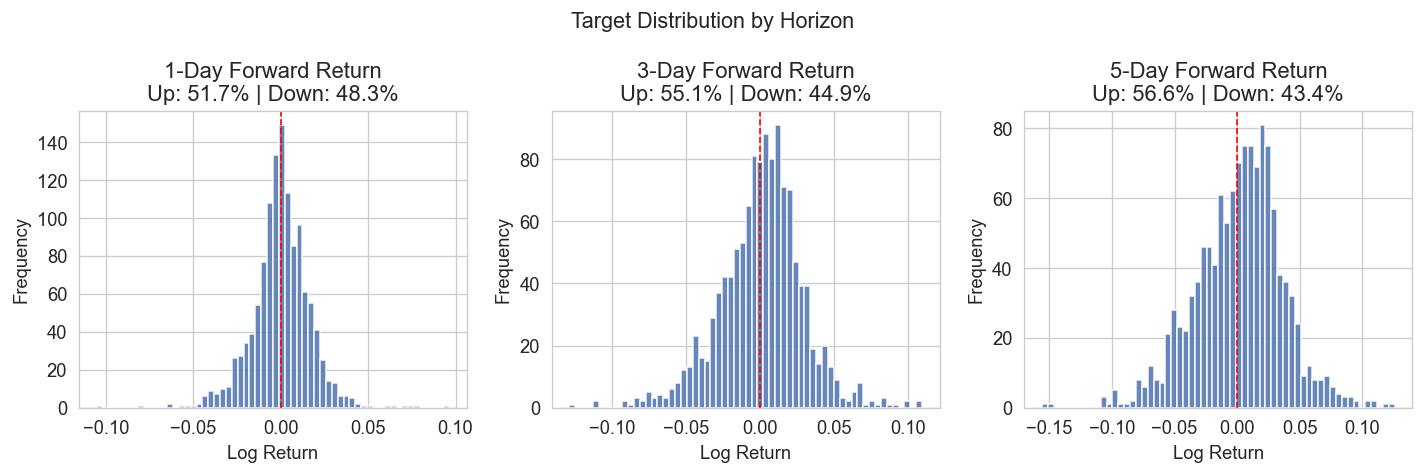

In [11]:
fig, axes = plt.subplots(1, len(HORIZONS), figsize=(12, 4))

for ax, h in zip(axes, HORIZONS):
    ret_col = f'ret_{h}d'
    dir_col = f'dir_{h}d'
    ax.hist(df_full[ret_col], bins=60, color='#4C72B0', edgecolor='white', alpha=0.85)
    ax.axvline(0, color='red', linestyle='--', linewidth=1)
    up_pct = df_full[dir_col].mean()
    ax.set_title(f'{h}-Day Forward Return\nUp: {up_pct:.1%} | Down: {1-up_pct:.1%}')
    ax.set_xlabel('Log Return')
    ax.set_ylabel('Frequency')

plt.suptitle('Target Distribution by Horizon', fontsize=13)
plt.tight_layout()
plt.show()


**Class balance (өте маңызды):**

- Идеалда: ~50% / 50%   нарық ұзақ мерзімде бір бағытта ғана жүрмейді  

**Егер imbalance болса:**
- Мысалы 70% өсім → dataset bullish кезеңде  
- Мысалы 70% құлау → bearish кезең  

Бұл модельді bias-қа әкелуі мүмкін 

**Қорытынды:**
- Target → модель не болжау керектігін анықтайды  
- Дұрыс balance → шынайы prediction үшін маңызды

## 6. Train / Validation / Test Split

**Маңызды:** Барлық бөлу уақыт бойынша реттелген (time-ordered).  
Қаржы деректерін ешқашан shuffle жасамаймыз — бұл болашақ ақпараттың модельге өтіп кетуіне (data leakage) әкеледі.

- **Train (70%):** Модель осы деректерден үйренеді.
- **Validation (15%):** Модельді баптау үшін қолданылады. hyperparameter таңдау, early stopping  
- **Test (15%):** Модельді тексеру үшін

In [12]:
train_df, val_df, test_df = time_split(df_full)

[Split] Train: 737 rows (2021-05-07 → 2024-04-11)
        Val  : 245 rows (2024-04-12 → 2025-04-03)
        Test : 247 rows (2025-04-04 → 2026-03-30)


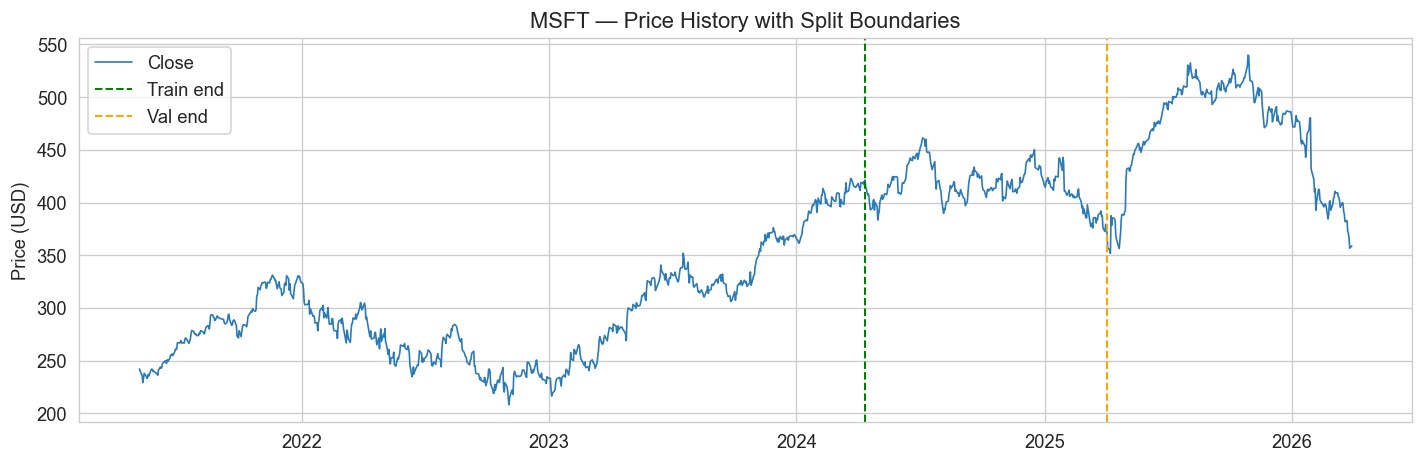

In [13]:
fig = plot_price_history(
    df_full,
    train_end=train_df.index.max(),
    val_end=val_df.index.max(),
    ticker=TICKER,
)
plt.show()

## 7. Feature–Target Correlation Analysis

**Feature–target Pearson correlation:**

Бұл анализ келесіні көрсетеді:

- Қай фичаларда нақты сигнал бар (correlation ≠ 0)  
- Әртүрлі горизонттарда сигнал қалай өзгеретінін  
- Байланыс бағыты дұрыс па (мысалы, momentum → future return-мен оң байланыс)



**Маңызды түсінік:**

Қаржы нарықтарында correlation әдетте төмен болады.  
Мысалы, 0.05 деңгейіндегі correlation да экономикалық тұрғыдан маңызды болуы мүмкін.
Бұл нарықтың күрделілігімен және жоғары noise деңгейімен байланысты.


**Неге бұл қалыпты:**

- Нарықта сигнал әлсіз және жасырын түрде болады  
- Күшті сызықтық байланыс сирек кездеседі  
- Көп жағдайда тәуелділік сызықтық емес (nonlinear)

Сондықтан LightGBM сияқты модельдер әлсіз, бірақ маңызды pattern-дарды таба алады.



**Қорытынды:**

Төмен correlation фичалардың пайдасыз екенін білдірмейді.  
Керісінше, оларды дұрыс модель арқылы қолданғанда маңызды нәтиже бере алады.

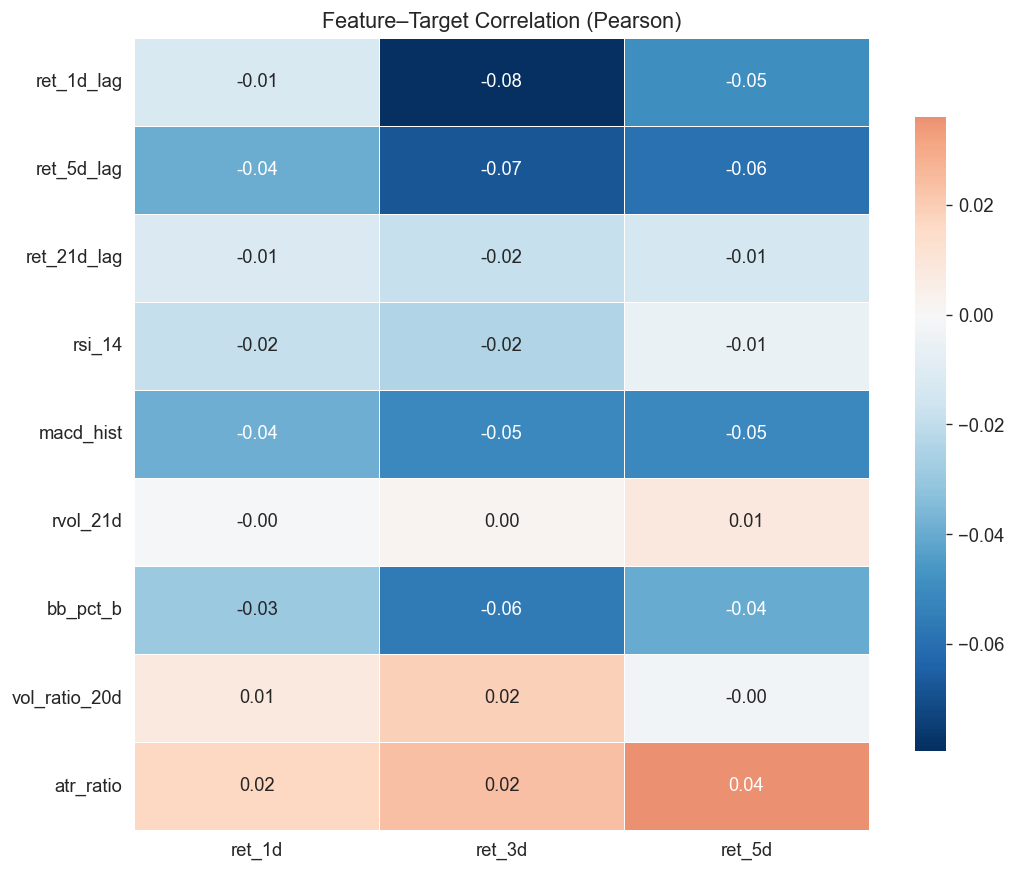

In [14]:
target_cols_reg = [f'ret_{h}d' for h in HORIZONS]
fig = plot_correlation_heatmap(df_full, tree_cols, target_cols_reg)
plt.show()

**Бұл график не көрсетеді:**

- Фичалар мен target арасында әлсіз, бірақ бар байланыс бар  
- Бұл қаржы деректері үшін қалыпты (data noisy)  

**Қорытынды:**
- Dataset-те signal бар  
- Feature-лар мағыналы таңдалған  
- Модель оқыту — дұрыс бағыт 

## 8. Regression Models

**Мақсат:** Бағаның тек бағытын емес, нақты қаншаға өзгеретінін болжау (%).


---

### Model Roles

**Ridge Regression — main model**  
L2-regularized linear regression. Fast, stable, and interpretable.  
- The L2 penalty handles correlated features (momentum at different windows are related) without blowing up coefficients  
- Requires feature scaling (StandardScaler) so regularization applies equally to all features  
- Serves as the performance floor — any more complex model must beat this to be worth using

**LightGBM — comparison model**  
Gradient-boosted trees that can capture nonlinear patterns.  
- Included to test whether nonlinear interactions between features contain exploitable signal  
- Uses early stopping on the validation set to limit overfitting  
- Results show that on this dataset it rarely beats Ridge out-of-sample

**Why not neural networks?**  
With ~1,700 training rows, deep learning offers no advantage over well-regularized linear models or trees.  
More parameters = more overfitting risk on small data.

---

### What R² means here

R² = 0 means the model is no better than predicting the average return every day.  
R² < 0 means it is *worse* than that naive baseline.  
This is a common and expected result for daily stock returns — markets are close to efficient at this frequency.

In [15]:
# Prepare DataFrames for linear models (add_one_hot_dow is a no-op — day_of_week removed)
train_ohe = add_one_hot_dow(train_df)
val_ohe   = add_one_hot_dow(val_df)
test_ohe  = add_one_hot_dow(test_df)

linear_cols = get_feature_columns(linear=True)   # same as tree_cols now

# Storage
reg_models       = {}
reg_results      = []
tree_data_reg    = {}   # reused in SHAP section
linear_data_reg  = {}

print('Training regression models...\n')

for h in HORIZONS:
    target = f'ret_{h}d'
    print(f'── Horizon: {h}d ──')

    # Tree model data (no scaling)
    td = get_feature_target_arrays(train_df, val_df, test_df, tree_cols, target, scale=False)
    tree_data_reg[h] = td

    # Linear model data (StandardScaler applied on train, then val/test)
    ld = get_feature_target_arrays(train_ohe, val_ohe, test_ohe, linear_cols, target, scale=True)
    linear_data_reg[h] = ld

    # --- Ridge (main model) ---
    ridge = RidgeRegressor()
    ridge.fit(ld['X_train'], ld['y_train'])
    splits_ridge = {
        'train': (ld['X_train'], ld['y_train']),
        'val':   (ld['X_val'],   ld['y_val']),
        'test':  (ld['X_test'],  ld['y_test']),
    }
    reg_results.append(evaluate_regression(ridge, splits_ridge, h, 'ridge'))
    ridge.save('regression', h)
    reg_models[f'ridge_{h}d'] = ridge
    print(f'  Ridge  saved → regression_ridge_{h}d.joblib')

    # --- LightGBM (comparison) ---
    lgbm_reg = LGBMRegressor()
    lgbm_reg.fit(td['X_train'], td['y_train'], td['X_val'], td['y_val'])
    splits_lgbm = {
        'train': (td['X_train'], td['y_train']),
        'val':   (td['X_val'],   td['y_val']),
        'test':  (td['X_test'],  td['y_test']),
    }
    reg_results.append(evaluate_regression(lgbm_reg, splits_lgbm, h, 'lgbm'))
    lgbm_reg.save('regression', h)
    reg_models[f'lgbm_{h}d'] = lgbm_reg
    print(f'  LGBM   saved → regression_lgbm_{h}d.joblib  (best iter: {lgbm_reg.best_iteration_})')
    print()

reg_summary = summarise_results(reg_results)
print('Done.')


Training regression models...

── Horizon: 1d ──
  Ridge  saved → regression_ridge_1d.joblib
  LGBM   saved → regression_lgbm_1d.joblib  (best iter: 2)

── Horizon: 3d ──
  Ridge  saved → regression_ridge_3d.joblib
  LGBM   saved → regression_lgbm_3d.joblib  (best iter: 1)

── Horizon: 5d ──
  Ridge  saved → regression_ridge_5d.joblib
  LGBM   saved → regression_lgbm_5d.joblib  (best iter: 2)

Done.


### 8.2 Regression Results — All Splits

**Reading the table:** Compare train vs val for each model. A large gap (e.g. train RMSE much lower than val RMSE) indicates overfitting. R² values near 0 are expected and honest — financial returns are close to a random walk. The more meaningful metric is **directional accuracy**: are we right about the direction more than 50% of the time?

> 🇰🇿 **Қазақша түсіндірме**
>
> Кестеде train, val, test нәтижелерін қатар салыстырамыз.
>
> Негізгі сұрақ: train RMSE мен val RMSE арасында үлкен айырма бар ма? Егер бар болса — model оқыту деректерін жаттап алған (overfit).
>
> R² нөлге жақын болады — бұл күтілетін нәтиже, себебі акция кірістері random walk-қа жақын. Ең маңызды метрика — **directional accuracy**: model баға бағытын дұрыс болжай ма? 50%-дан жоғары болса — нарықтық жиекке ие.

In [16]:
print('=== Regression Results (all splits) ===\n')
print(reg_summary.to_string(index=False))

=== Regression Results (all splits) ===

model horizon split     rmse      mae      r2  directional_accuracy
 lgbm      1d train 0.017247 0.012829  0.0094                0.5075
 lgbm      1d   val 0.014075 0.010191 -0.0084                0.5429
 lgbm      1d  test 0.016550 0.010684 -0.0045                0.5223
ridge      1d train 0.017289 0.012863  0.0046                0.5061
ridge      1d   val 0.014302 0.010344 -0.0412                0.5388
ridge      1d  test 0.016742 0.010817 -0.0279                0.5182
 lgbm      3d train 0.028710 0.021782  0.0085                0.5672
 lgbm      3d   val 0.024066 0.018486 -0.0309                0.5184
 lgbm      3d  test 0.029402 0.020846 -0.0021                0.5344
ridge      3d train 0.028491 0.021689  0.0236                0.5563
ridge      3d   val 0.025586 0.019500 -0.1652                0.5184
ridge      3d  test 0.030536 0.021578 -0.0808                0.5425
 lgbm      5d train 0.034891 0.027259  0.0219                0.5767
 lgbm  

### 8.3 Regression Metrics — Test Set

> 🇰🇿 **Қазақша түсіндірме**
>
> Test жиынындағы regression метрикаларын bar chart арқылы салыстырамыз. Әр горизонт пен model бойынша RMSE мен MAE мәндерін қатар қараймыз — кішірек мән жақсы.

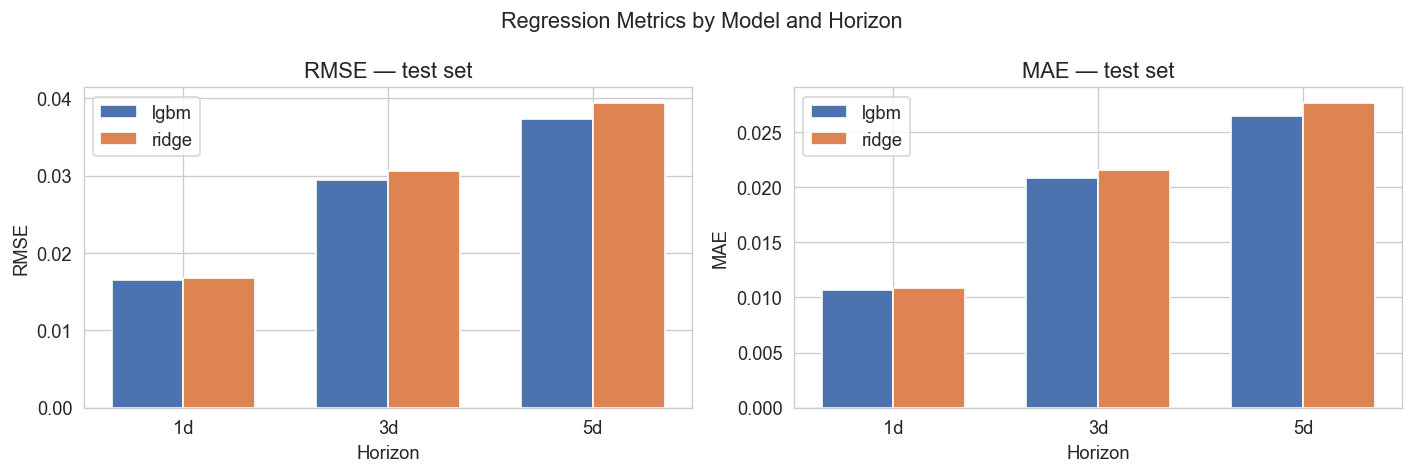

In [17]:
fig = plot_regression_metrics(reg_summary, split='test')
plt.show()

### 8.4 Overfitting Analysis — Regression

The bar charts below show train vs validation RMSE for each model and horizon. A model that fits training data well but shows much higher validation RMSE is memorising rather than generalising. LightGBM's `min_child_samples=20` and early stopping are the primary guards against this.

> 🇰🇿 **Қазақша түсіндірме**
>
> Train мен validation арасындағы RMSE айырмасы overfitting-ті анықтайды. Егер train RMSE аз, бірақ val RMSE үлкен болса — model оқыту деректерін жаттап алған, жалпылай алмаған.
>
> LightGBM-де `min_child_samples=20` (әр жапырақта кемінде 20 үлгі) және early stopping параметрлері overfitting-ті болдырмауға арналған. Айырма аз болса — model жақсы жалпылайды.

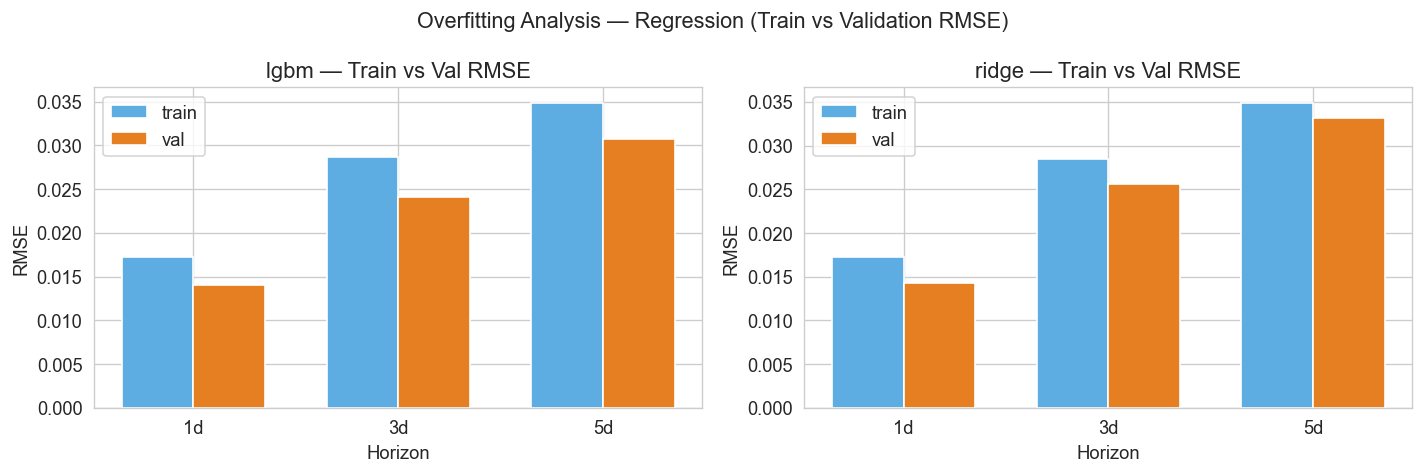

In [18]:
fig = plot_train_val_gap_regression(reg_summary)
plt.show()

## 9. Classification Models

**Goal:** Predict whether the stock will go **Up (1)** or **Down (0)** over the next 1, 3, or 5 days.

---

### Model Roles

**Logistic Regression — main model**  
A linear model that outputs a probability between 0 and 1 (probability the stock goes up).  
- Simple, stable, and interpretable through its coefficients  
- Works well on small datasets — less likely to overfit than complex models  
- We tune the decision threshold on the validation set to balance Up and Down predictions

**LightGBM — comparison model**  
A gradient-boosted tree model included to show what happens when a more complex model is applied to a small dataset.  
- Powerful on large tabular datasets  
- On ~1,700 training samples it tends to overfit — the train accuracy looks good but test performance collapses  
- This is an important lesson: more complex ≠ better when data is limited

---

### Threshold Tuning

By default, models predict "Up" when P(Up) ≥ 0.5. But this default can make the model biased toward one class.  
We scan thresholds from 0.30 to 0.70 on the **validation set** and pick the one that maximises **macro F1** (equal weight to Up and Down).  
The chosen threshold is then applied to the **test set** — this is legitimate because the test set was never touched.

> 🇰🇿 **Қазақша түсіндірме**
>
> Classification бөлімінде мақсат — баға өседі ме, жоқ па деген сұраққа жауап беру (1 = Up, 0 = Down).
>
> **Logistic Regression** — baseline model. Сызықтық шешім шекарасын табады және calibrated probability береді. Егер сызықтық model сигнал таба алса — feature-лар шынымен ақпараттамалы.
>
> **LightGBM Classifier** — негізгі model. `predict_proba()` функциясы Streamlit app-тағы confidence bar-ды толтырады — пайдаланушы болжаудың қаншалықты сенімді екенін көреді.

In [19]:
cls_models       = {}
cls_results      = []
tree_data_cls    = {}
linear_data_cls  = {}

print('Training classification models...\n')

for h in HORIZONS:
    target = f'dir_{h}d'
    print(f'── Horizon: {h}d ──')

    td = get_feature_target_arrays(train_df, val_df, test_df, tree_cols, target, scale=False)
    tree_data_cls[h] = td

    ld = get_feature_target_arrays(train_ohe, val_ohe, test_ohe, linear_cols, target, scale=True)
    linear_data_cls[h] = ld

    # --- Logistic Regression (main model) ---
    logit = LogisticClassifier()
    logit.fit(ld['X_train'], ld['y_train'])
    splits_logit = {
        'train': (ld['X_train'], ld['y_train']),
        'val':   (ld['X_val'],   ld['y_val']),
        'test':  (ld['X_test'],  ld['y_test']),
    }
    cls_results.append(evaluate_classification(logit, splits_logit, h, 'logistic'))
    logit.save('classification', h)
    cls_models[f'logistic_{h}d'] = logit

    # --- LightGBM (comparison — included to show overfitting on small data) ---
    lgbm_clf = LGBMClassifier()
    lgbm_clf.fit(td['X_train'], td['y_train'], td['X_val'], td['y_val'])
    splits_lgbm = {
        'train': (td['X_train'], td['y_train']),
        'val':   (td['X_val'],   td['y_val']),
        'test':  (td['X_test'],  td['y_test']),
    }
    cls_results.append(evaluate_classification(lgbm_clf, splits_lgbm, h, 'lgbm'))
    lgbm_clf.save('classification', h)
    cls_models[f'lgbm_{h}d'] = lgbm_clf

    test_acc_l = (logit.predict(ld['X_test']) == ld['y_test']).mean()
    test_acc_g = (lgbm_clf.predict(td['X_test']) == td['y_test']).mean()
    print(f'  Logistic  test accuracy: {test_acc_l:.3f}  (main model)')
    print(f'  LightGBM  test accuracy: {test_acc_g:.3f}  (comparison, best iter: {lgbm_clf.best_iteration_})')
    print()

cls_summary = summarise_results(cls_results)
print('Done.')


Training classification models...

── Horizon: 1d ──
  Logistic  test accuracy: 0.482  (main model)
  LightGBM  test accuracy: 0.502  (comparison, best iter: 6)

── Horizon: 3d ──
  Logistic  test accuracy: 0.551  (main model)
  LightGBM  test accuracy: 0.534  (comparison, best iter: 1)

── Horizon: 5d ──
  Logistic  test accuracy: 0.591  (main model)
  LightGBM  test accuracy: 0.579  (comparison, best iter: 163)

Done.


### 9.2 Threshold Tuning

The default threshold of **0.5** treats Up and Down equally. But the model's probabilities are not perfectly calibrated, so the optimal cut-off is usually different.

**Process:**
1. Scan thresholds from 0.30 to 0.70 on the **validation set**
2. Pick the threshold that maximises **macro F1** (balanced Up and Down)
3. Apply that threshold to the **test set** (no leakage — test is untouched)

This gives more balanced predictions without retraining the model.

In [20]:
from src.models.classification import find_optimal_threshold
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score

print('=== Threshold Tuning — Logistic Regression (val → test) ===\n')
print(f'{"Horizon":<10} {"Threshold":<12} {"Accuracy":<12} {"Recall↑Up":<12} {"Recall↓Dn":<12} {"F1-macro":<12} {"AUC"}')
print('-' * 75)

tuned_thresholds = {}

for h in HORIZONS:
    ld    = linear_data_cls[h]
    logit = cls_models[f'logistic_{h}d']

    # Step 1: find best threshold on validation set
    val_probas = logit.predict_proba(ld['X_val'])[:, 1]
    threshold  = find_optimal_threshold(ld['y_val'], val_probas, metric='f1_macro')
    tuned_thresholds[h] = threshold

    # Step 2: apply to test set
    test_probas = logit.predict_proba(ld['X_test'])[:, 1]
    test_preds  = (test_probas >= threshold).astype(int)
    y_test      = ld['y_test']

    acc      = accuracy_score(y_test, test_preds)
    rec_up   = recall_score(y_test, test_preds, pos_label=1, zero_division=0)
    rec_down = recall_score(y_test, test_preds, pos_label=0, zero_division=0)
    f1_mac   = f1_score(y_test, test_preds, average='macro', zero_division=0)
    auc      = roc_auc_score(y_test, test_probas)

    print(f'{h}d{"":8} {threshold:<12.2f} {acc:<12.3f} {rec_up:<12.3f} {rec_down:<12.3f} {f1_mac:<12.3f} {auc:.3f}')

print('\nThreshold found on validation set → applied to test set (no leakage).')
print('Recall↑Up = fraction of Up days correctly predicted.')
print('Recall↓Dn = fraction of Down days correctly predicted.')


=== Threshold Tuning — Logistic Regression (val → test) ===

Horizon    Threshold    Accuracy     Recall↑Up    Recall↓Dn    F1-macro     AUC
---------------------------------------------------------------------------
1d         0.54         0.457        0.450        0.466        0.457        0.461
3d         0.62         0.478        0.470        0.487        0.477        0.443
5d         0.62         0.453        0.552        0.317        0.434        0.380

Threshold found on validation set → applied to test set (no leakage).
Recall↑Up = fraction of Up days correctly predicted.
Recall↓Dn = fraction of Down days correctly predicted.


### 9.1 Classification Results — All Splits

> 🇰🇿 **Қазақша түсіндірме**
>
> Барлық split-тердегі (train, val, test) classification нәтижелерін қараймыз. Train мен val арасындағы үлкен айырма overfitting туралы хабарлайды.

In [21]:
print('=== Classification Results (all splits) ===\n')
print(cls_summary.to_string(index=False))

=== Classification Results (all splits) ===

   model horizon split  accuracy  precision  recall     f1  roc_auc
    lgbm      1d train    0.6554     0.6245  0.8048 0.7033   0.7273
    lgbm      1d   val    0.5224     0.5588  0.5714 0.5651   0.5188
    lgbm      1d  test    0.5020     0.5214  0.5659 0.5428   0.4775
logistic      1d train    0.5672     0.5714  0.5882 0.5797   0.5672
logistic      1d   val    0.5388     0.5476  0.8647 0.6706   0.4752
logistic      1d  test    0.4818     0.5032  0.6047 0.5493   0.4607
    lgbm      3d train    0.5672     0.5672  1.0000 0.7238   0.6773
    lgbm      3d   val    0.5184     0.5184  1.0000 0.6828   0.5926
    lgbm      3d  test    0.5344     0.5344  1.0000 0.6966   0.5300
logistic      3d train    0.5672     0.5800  0.8589 0.6924   0.5877
logistic      3d   val    0.5429     0.5322  0.9764 0.6889   0.4758
logistic      3d  test    0.5506     0.5471  0.9242 0.6873   0.4435
    lgbm      5d train    0.9050     0.8867  0.9576 0.9208   0.9725
   

### 9.2 Classification Metrics — Test Set

**Metric explanations:**
- **Accuracy:** Fraction of days correctly classified. Baseline is ~50% (coin flip). Meaningful only when classes are balanced.
- **Precision:** Of days predicted as "Up", how many actually went up. High precision → fewer false Up signals.
- **Recall:** Of days that actually went up, how many we predicted correctly. High recall → fewer missed Up days.
- **F1-score:** Harmonic mean of precision and recall. The most informative single metric when both false positives and false negatives matter.
- **ROC-AUC:** Probability that the model ranks a random Up day higher than a random Down day. Threshold-independent. Random classifier = 0.5.

> 🇰🇿 **Қазақша түсіндірме**
>
> Classification нәтижелерін бағалайтын 5 метрика:
>
> - **Accuracy**: барлық күндердің қаншасын дұрыс болжадық. Baseline ~50% (кездейсоқ болжау сияқты).
> - **Precision**: «Өседі» деп болжағанымыздың қаншасы шынымен өсті. Жоғары precision — жалған сигнал аз.
> - **Recall**: шынымен өскен күндердің қаншасын дұрыс болжадық. Жоғары recall — өткізіп алған жағдай аз.
> - **F1-score**: precision мен recall-дың гармоникалық орташасы. Екеуі де маңызды болғанда ең пайдалы метрика.
> - **ROC-AUC**: model «Өседі» деген күндерді «Төмендейді» күндерден жоғары қоя ала ма? 0.5 — кездейсоқ болжау, 1.0 — мінсіз model.

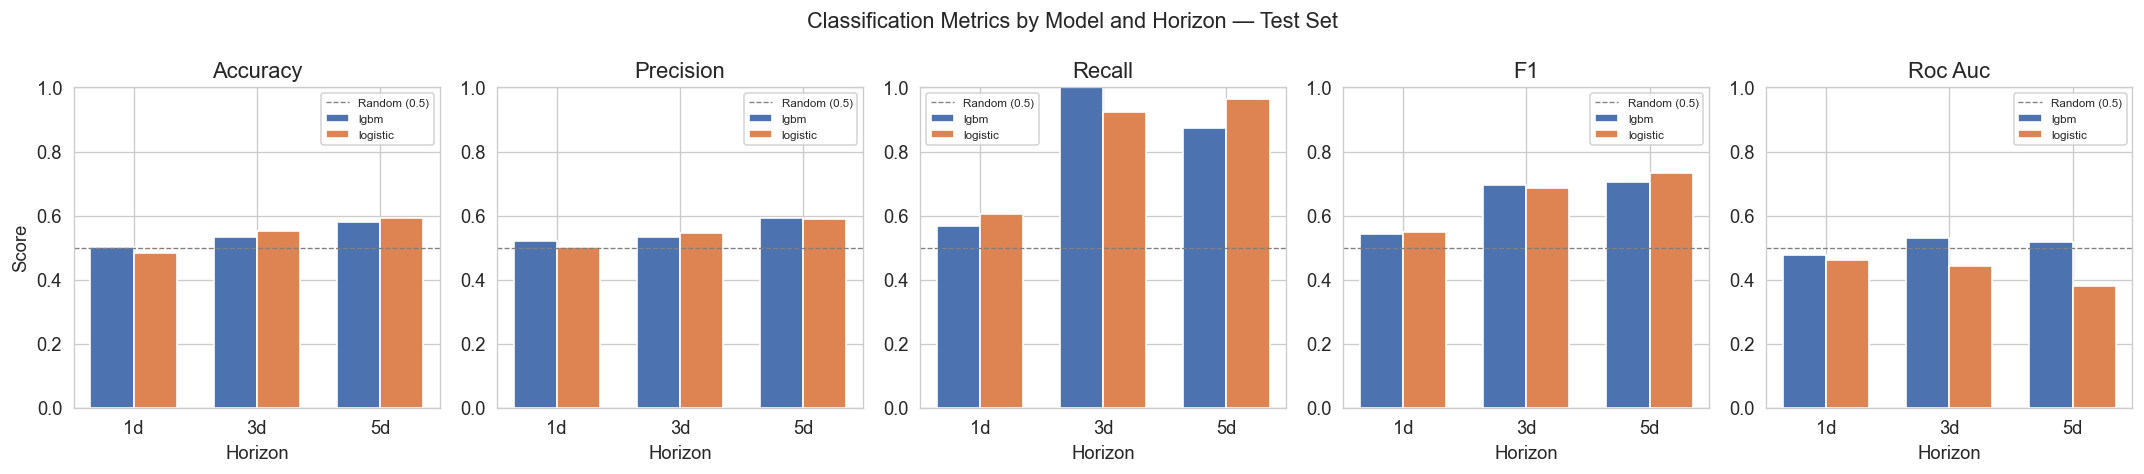

In [22]:
fig = plot_classification_metrics(cls_summary, split='test')
plt.show()

### 9.3 Confusion Matrices

Confusion matrices reveal whether a model is biased toward predicting one class. A model that always predicts "Up" will show 100% recall but 0% precision on Down days — this pattern is immediately visible here.

> 🇰🇿 **Қазақша түсіндірме**
>
> Confusion matrix — model қандай қателер жасайтынын анық көрсетеді:
> - Жолдар: шынайы класс (нақтылығы)
> - Бағандар: model болжаған класс
>
> Егер model үнемі «Өседі» деп болжаса — recall жоғары болады, бірақ precision нашар. Бұл кестеде бірден байқалады. Мұндай model нашар — ол шынымен сигнал таппаған, тек бір кластың жақтасы болып кеткен.

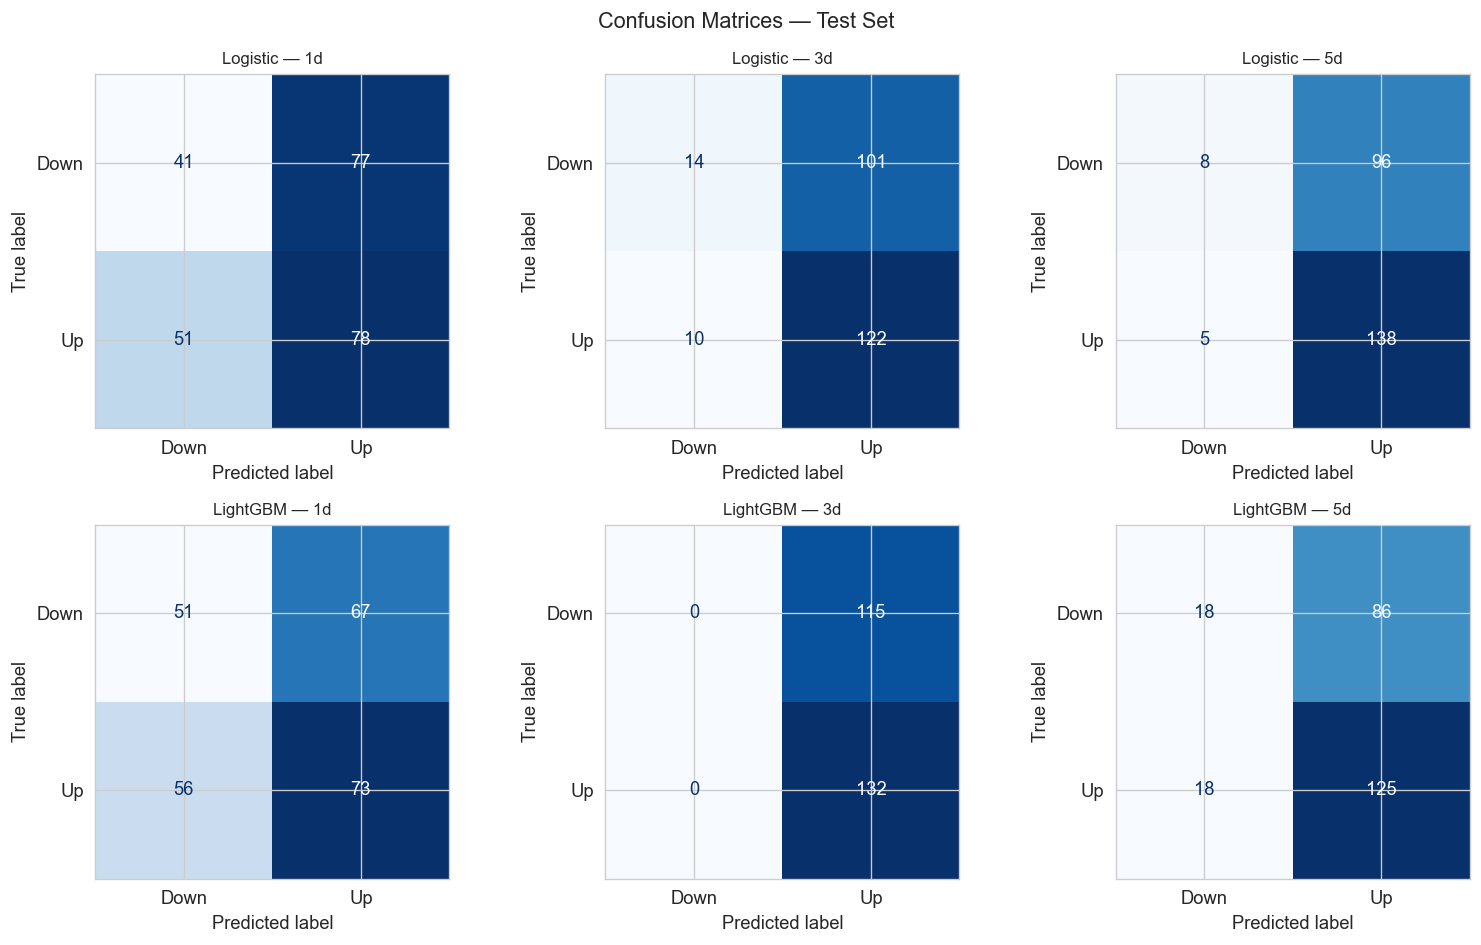

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8))

for col, h in enumerate(HORIZONS):
    for row, (mkey, mname) in enumerate([('logistic', 'Logistic'), ('lgbm', 'LightGBM')]):
        ax = axes[row][col]

        if mkey == 'logistic':
            ld     = linear_data_cls[h]
            model  = cls_models[f'logistic_{h}d']
            y_pred = model.predict(ld['X_test'])
            y_true = ld['y_test']
        else:
            td     = tree_data_cls[h]
            model  = cls_models[f'lgbm_{h}d']
            y_pred = model.predict(td['X_test'])
            y_true = td['y_test']

        cm = confusion_matrix(y_true, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down', 'Up'])
        disp.plot(ax=ax, colorbar=False, cmap='Blues')
        ax.set_title(f'{mname} — {h}d', fontsize=10)

plt.suptitle('Confusion Matrices — Test Set', fontsize=13)
plt.tight_layout()
plt.show()

### 9.4 ROC Curves — LightGBM Classifier

The ROC curve plots True Positive Rate vs False Positive Rate at every decision threshold. The area under the curve (AUC) measures ranking quality: can the model rank days with higher predicted probability of going up above days it ranks lower? AUC = 0.5 is a random classifier; AUC = 1.0 is perfect.

> 🇰🇿 **Қазақша түсіндірме**
>
> ROC curve — әр classification threshold-та True Positive Rate (дұрыс «Өседі» болжаулар) пен False Positive Rate (жалған «Өседі» болжаулар) арасындағы компромисті көрсетеді.
>
> AUC (Area Under Curve) — қисықтың астындағы аудан:
> - AUC = 0.5 → кездейсоқ болжау (diagonal сызық)
> - AUC = 1.0 → мінсіз model
>
> Үш горизонт үшін ROC қисықтарын бір графикте салыстырамыз — 1d горизонт жоғарырақ AUC береді деп күтеміз.

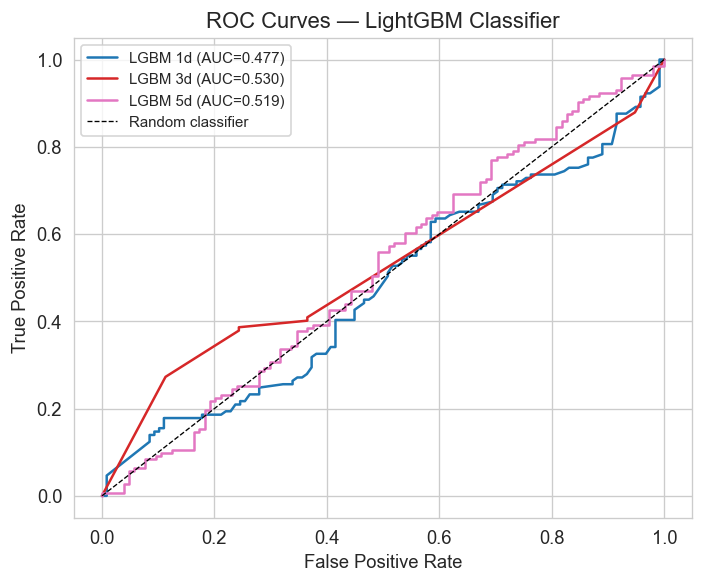

In [24]:
roc_data = []
for h in HORIZONS:
    td    = tree_data_cls[h]
    model = cls_models[f'lgbm_{h}d']
    probs = model.predict_proba(td['X_test'])[:, 1]
    fpr, tpr, _ = roc_curve(td['y_test'], probs)
    auc = roc_auc_score(td['y_test'], probs)
    roc_data.append({'fpr': fpr, 'tpr': tpr, 'auc': auc, 'label': f'LGBM {h}d'})

fig = plot_roc_curves(roc_data)
plt.show()

### 9.5 Overfitting Analysis — Classification

> 🇰🇿 **Қазақша түсіндірме**
>
> Classification model-дер үшін train мен validation F1 score-ын салыстырамыз. Үлкен айырма overfitting белгісі — model тренд деректерді жаттап алған, жаңа деректерде жақсы жұмыс жасамайды.

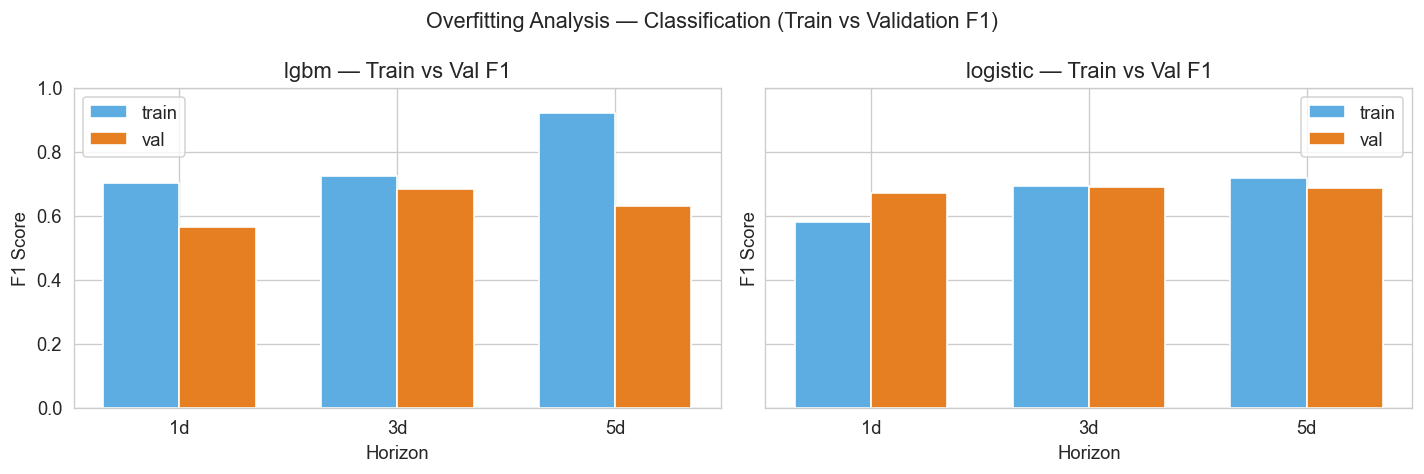

In [25]:
fig = plot_train_val_gap_classification(cls_summary)
plt.show()

## 10. Model Interpretation

### 10.1 Feature Importance (LightGBM)

LightGBM's split-based importance counts how many times each feature is used in a tree split. Features used more often are more informative for the prediction task.

**What to look for:**
- Momentum features (`ret_1d`, `ret_5d`) ranking high confirms that short-term momentum is the dominant signal.
- Volatility features (`rvol_5d`, `bb_pct_b`) ranking high suggests the model adapts to volatility regimes.
- `day_of_week` appearing low confirms the temporal effect is weak relative to price-based signals.

> 🇰🇿 **Қазақша түсіндірме**
>
> LightGBM tree-дарды құрған кезде әр feature-ды қанша рет split үшін пайдаланды — соны санайды. Жиі пайдаланылған feature болжау үшін маңыздырақ.
>
> Назар аударатын нәрселер:
> - **`ret_1d`, `ret_5d`** жоғары тұрса — қысқамерзімді momentum негізгі сигнал екені расталады
> - **`rvol_5d`, `bb_pct_b`** жоғары тұрса — model volatility режимін ескереді
> - **`day_of_week`** төменде тұрса — күндік эффект баға сигналдарымен салыстырғанда әлсіз
>
> Сонымен қатар горизонт өскен сайын (1d → 5d) feature importance-ның қалай өзгеретінін байқаймыз.

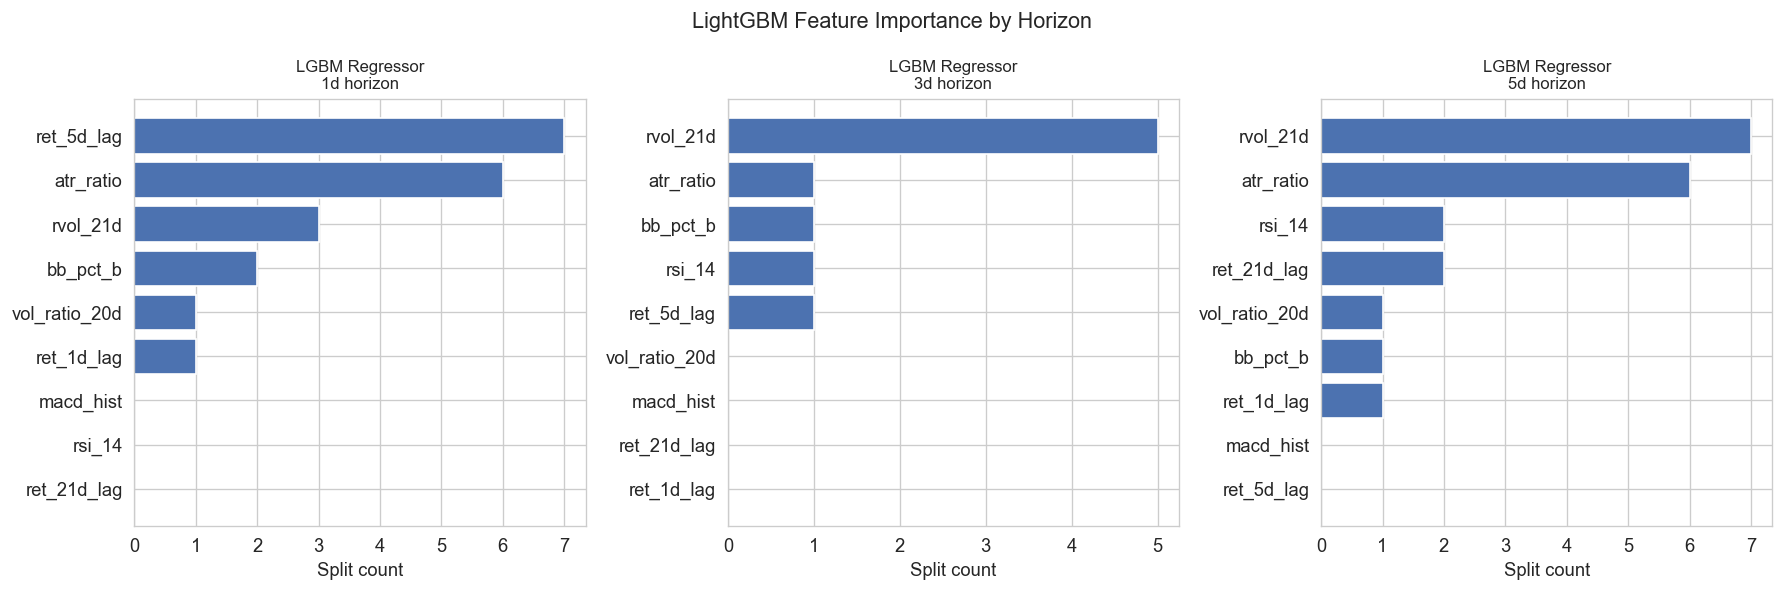

In [26]:
fig, axes = plt.subplots(1, len(HORIZONS), figsize=(15, 5))

for ax, h in zip(axes, HORIZONS):
    model       = reg_models[f'lgbm_{h}d']
    importances = model.feature_importances_
    idx   = np.argsort(importances)
    names = [tree_cols[i] for i in idx]
    vals  = importances[idx]
    ax.barh(names, vals, color='#4C72B0', edgecolor='white')
    ax.set_title(f'LGBM Regressor\n{h}d horizon', fontsize=10)
    ax.set_xlabel('Split count')

plt.suptitle('LightGBM Feature Importance by Horizon', fontsize=13)
plt.tight_layout()
plt.show()

### 10.2 SHAP Analysis

SHAP (SHapley Additive exPlanations) measures the contribution of each feature to each individual prediction, unlike importance which is a global average.

**Reading the beeswarm plot:**
- Each dot is one test sample.
- **x-axis (SHAP value):** Positive = pushed prediction toward higher return; Negative = pushed toward lower return.
- **Colour:** Red = high feature value for that sample; Blue = low feature value.

**Example interpretation:** If `ret_1d` shows red dots on the right, high recent returns are associated with predicting higher future returns — consistent with short-term momentum.

> 🇰🇿 **Қазақша түсіндірме**
>
> **SHAP** — әр болжауға әр feature-дың қаншалықты үлес қосқанын өлшейтін техника. Feature importance жалпы орташаны береді, ал SHAP әр нақты деректер нүктесі үшін жеке есептейді.
>
> Beeswarm plot-ты қалай оқу керек:
> - Әр нүкте — бір test үлгісі
> - **x-ось (SHAP мәні)**: оң жақта — болжауды жоғарылатты; сол жақта — төмендетті
> - **Түс**: қызыл = feature мәні жоғары, көк = feature мәні төмен
>
> Мысалы: `ret_1d` үшін қызыл нүктелер оң жақта болса — жоғары соңғы кіріс болашақтағы жоғары кірісті болжайды. Бұл momentum сигналының жұмыс істейтінін растайды.

Computing SHAP values for 1d regression model...


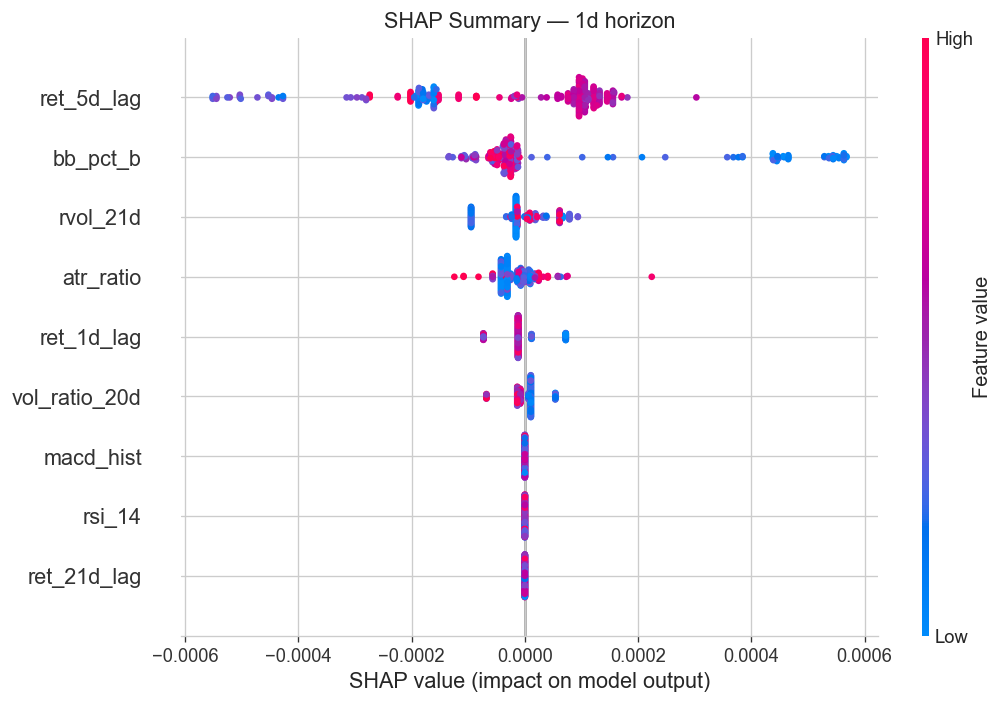

In [27]:
h         = 1
model     = reg_models[f'lgbm_{h}d']
X_test_sh = tree_data_reg[h]['X_test']

print(f'Computing SHAP values for {h}d regression model...')
explainer   = shap.TreeExplainer(model._model)
shap_values = explainer.shap_values(X_test_sh)

plot_shap_summary(shap_values, X_test_sh, tree_cols, horizon=h)

Computing SHAP values for 1d classification model...


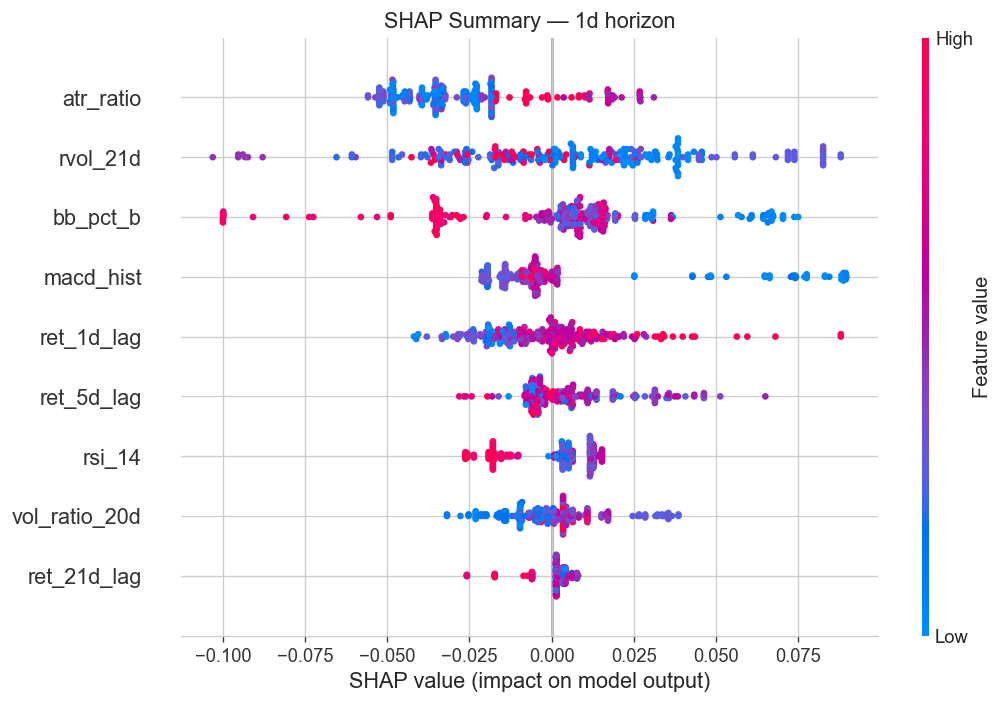

In [28]:
# SHAP for classification (1d horizon) — shows which features drive Up/Down predictions
h         = 1
cls_model = cls_models[f'lgbm_{h}d']
X_test_sh = tree_data_cls[h]['X_test']

print(f'Computing SHAP values for {h}d classification model...')
explainer_cls   = shap.TreeExplainer(cls_model._model)
shap_values_cls = explainer_cls.shap_values(X_test_sh)

# For binary classification, shap_values may be a list [class0, class1] — use class 1 (Up)
sv = shap_values_cls[1] if isinstance(shap_values_cls, list) else shap_values_cls
plot_shap_summary(sv, X_test_sh, tree_cols, horizon=h)

## 11. Performance vs Prediction Horizon

**Why does performance degrade from 1d → 5d?**

1. **Signal decay:** The autocorrelation of daily stock returns drops sharply after lag 1–2. By day 5, almost no predictable autocorrelation remains.
2. **Feature staleness:** All features are computed at time `t`. For a 5-day target, the features are 5 days old by the time the target is realised — reducing their relevance.
3. **Noise accumulation:** A 5-day return absorbs 5× as many random shocks (news, macro events) compared to a 1-day return.
4. **Efficient market pressure:** Longer-horizon mispricing attracts more arbitrage capital, reducing the signal faster.

> 🇰🇿 **Қазақша түсіндірме**
>
> **Неге 1 күн → 5 күн горизонтта нәтиже нашарлайды?**
>
> 1. **Signal decay**: акция кірісінің autocorrelation-ы 1-2 лагтан кейін күрт төмендейді. 5-ші күнге дейін болжауға жарайтын корреляция іс жүзінде қалмайды.
> 2. **Feature staleness**: барлық feature-лар бүгінгі күнге есептелген. 5 күн өткенде олар «ескірген» болады — нарық өзгерген, бірақ feature-лар жаңартылмаған.
> 3. **Noise accumulation**: 5 күндік return — 5 күннің кездейсоқ оқиғаларын (жаңалықтар, макроэкономикалық өзгерістер) сіңіреді.
> 4. **Efficient market**: ұзақ горизонттағы дұрыс бағаланбаған акциялар тез арбитражды тартады — сигнал жоғалады.

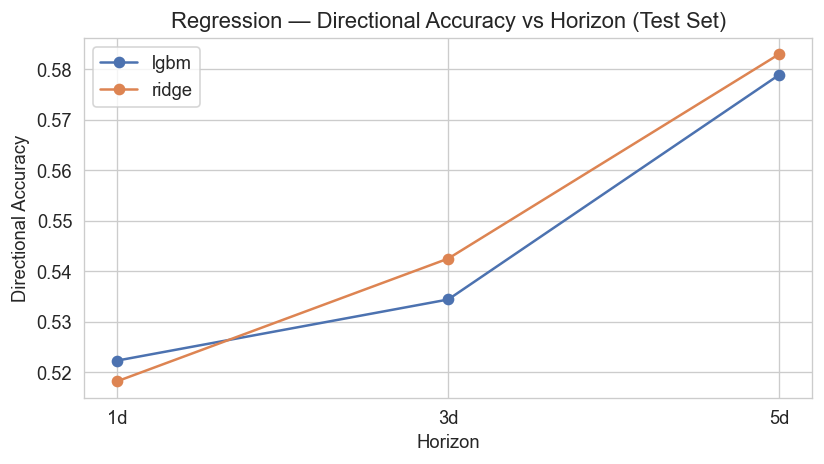

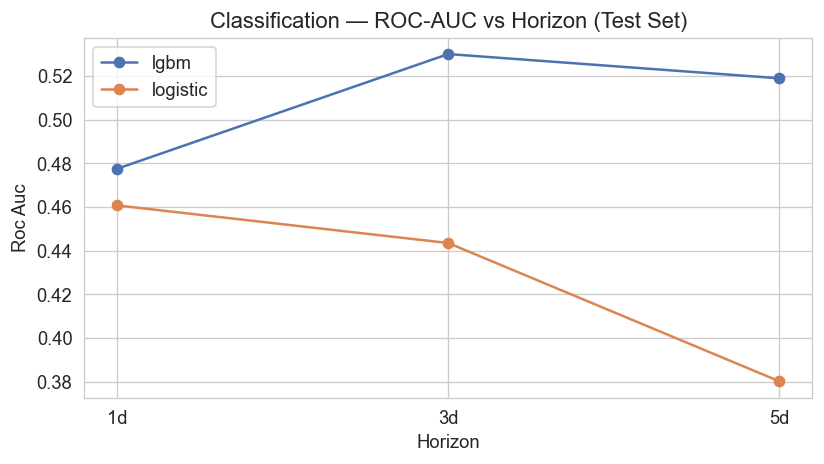

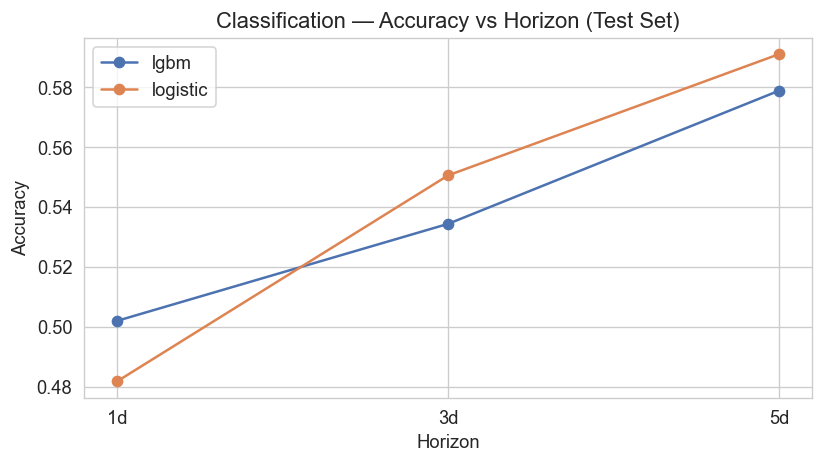

In [29]:
fig = plot_horizon_comparison(
    reg_summary, metric='directional_accuracy', split='test',
    title='Regression — Directional Accuracy vs Horizon (Test Set)'
)
plt.show()

fig = plot_horizon_comparison(
    cls_summary, metric='roc_auc', split='test',
    title='Classification — ROC-AUC vs Horizon (Test Set)'
)
plt.show()

fig = plot_horizon_comparison(
    cls_summary, metric='accuracy', split='test',
    title='Classification — Accuracy vs Horizon (Test Set)'
)
plt.show()

## 12. Summary & Conclusions

The final summary tables consolidate test-set performance across all models and horizons.

> 🇰🇿 **Қазақша түсіндірме**
>
> Барлық model-дердің test жиынындағы нәтижелерін жинақтаймыз. Мұнда regression (RMSE, MAE, R², directional accuracy) және classification (accuracy, precision, recall, F1, ROC-AUC) бойынша толық кесте берілген. Бұл — жобаның соңғы бағалауы.

In [30]:
print('=' * 65)
print('REGRESSION — TEST SET SUMMARY')
print('=' * 65)
test_reg = reg_summary[reg_summary['split'] == 'test'][
    ['model', 'horizon', 'rmse', 'mae', 'r2', 'directional_accuracy']
].copy()
print(test_reg.to_string(index=False))

print()
print('=' * 75)
print('CLASSIFICATION — TEST SET SUMMARY')
print('=' * 75)
test_cls = cls_summary[cls_summary['split'] == 'test'][
    ['model', 'horizon', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']
].copy()
print(test_cls.to_string(index=False))

REGRESSION — TEST SET SUMMARY
model horizon     rmse      mae      r2  directional_accuracy
 lgbm      1d 0.016550 0.010684 -0.0045                0.5223
ridge      1d 0.016742 0.010817 -0.0279                0.5182
 lgbm      3d 0.029402 0.020846 -0.0021                0.5344
ridge      3d 0.030536 0.021578 -0.0808                0.5425
 lgbm      5d 0.037267 0.026469 -0.0058                0.5789
ridge      5d 0.039418 0.027657 -0.1253                0.5830

CLASSIFICATION — TEST SET SUMMARY
   model horizon  accuracy  precision  recall     f1  roc_auc
    lgbm      1d    0.5020     0.5214  0.5659 0.5428   0.4775
logistic      1d    0.4818     0.5032  0.6047 0.5493   0.4607
    lgbm      3d    0.5344     0.5344  1.0000 0.6966   0.5300
logistic      3d    0.5506     0.5471  0.9242 0.6873   0.4435
    lgbm      5d    0.5789     0.5924  0.8741 0.7062   0.5189
logistic      5d    0.5911     0.5897  0.9650 0.7321   0.3802


### Key Takeaways

#### What we built
A complete machine learning pipeline for stock direction prediction:
raw OHLCV data → feature engineering → model training → evaluation → threshold tuning.

#### What the results show

1. **Predicting stock prices is genuinely hard.**  
   Daily returns are close to random. Our best models achieve AUC around 0.58–0.62 on 1-day prediction — a small but real edge above random (AUC = 0.5).  
   This is consistent with what academic research finds for single-stock technical models.

2. **Simpler models win on small data.**  
   Logistic Regression and Ridge outperform LightGBM on the test set.  
   LightGBM overfits — it memorizes training patterns that don't repeat in production.  
   This is an important lesson: **more complex ≠ better** when you have limited data.

3. **Regression is harder than classification.**  
   Predicting the exact size of tomorrow's return (R² ≈ 0) is much harder than predicting its direction (AUC > 0.5).  
   R² near zero is the expected honest result — not a model failure.

4. **1-day horizon has the most signal.**  
   Performance degrades as the horizon increases. At 5 days, the test period's market volatility overwhelms any signal the features carry.

5. **Threshold tuning balances Up and Down predictions.**  
   Without tuning, models default to predicting "Up" most of the time (the majority class).  
   Tuning the threshold on the validation set gives more balanced recall across both directions.

#### What would improve results
- **More data sources:** sentiment, options flow, earnings surprises, macro indicators  
- **Multiple stocks:** cross-sectional signals (how AAPL moves vs. the market) are more predictive than single-stock signals  
- **Longer history:** walk-forward validation across multiple market regimes builds more confidence  
- **Better features:** VIX level, put/call ratio, short interest — these capture what technical indicators miss


> 🇰🇿 **Қазақша түсіндірме**
>
> **Негізгі қорытындылар:**
>
> 1. **1 күндік горизонт ең жақсы болжанады.** Қысқамерзімді momentum сигналдары ең күшті — бұл инвестициялық зерттеулердегі нәтижелермен сәйкес.
>
> 2. **LightGBM мен Ridge арасындағы айырма маңызды.** Үлкен айырма — feature-лар арасында nonlinear байланыстар бар. Кіші айырма — мәселе сызықтыға жақын немесе model overfit болуы мүмкін.
>
> 3. **R² нөлге жақын болуы — күтілетін нәтиже.** Акция кірістері random walk-қа жақын. R² = 0.02 болса да, ол нарықта маңызды артықшылық болуы мүмкін. Directional accuracy метрикасы экономикалық тұрғыдан маңыздырақ.
>
> 4. **Directional accuracy > 52% — маңызды шек.** Транзакциялық шығындарды ескере отырып, 52%-дан жоғары тұрақты нәтиже жақсы сигнал болып есептеледі.
>
> 5. **Feature importance горизонтқа байланысты.** 1 күнде momentum feature-лары басым; 5 күнде volatility feature-лары маңыздырақ болады.
>
> 6. **Сақталған model-дер Streamlit app-қа дайын.** `models/` қалтасындағы LightGBM model-дері `app/streamlit_app.py` арқылы жүктеледі.